# Setup

## Load Results

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[2]  # adjust if notebook is nested
sys.path.append(str(PROJECT_ROOT))

print("Added to PYTHONPATH:", PROJECT_ROOT)

Added to PYTHONPATH: c:\Users\yfess\Desktop\timeseries-thesis


In [7]:
from dotenv import load_dotenv
import os

env_file = PROJECT_ROOT / ".env"

print( env_file.exists())

load_dotenv(env_file)

print("Loaded env file:", env_file)
print("DB PORT:", os.getenv("MONGODB_PORT"))

True
Loaded env file: c:\Users\yfess\Desktop\timeseries-thesis\.env
DB PORT: 27067


In [8]:
# from src.databases.benchmark_db.models import Benchmark 
from src.common.config import load_config
from src.common.logger import get_logger
from src.databases.benchmark_db.config import get_postgres_config
from src.databases.benchmark_db.benchmark_db import BenchmarkDB

In [9]:
bmdb_config_file_path = PROJECT_ROOT / "configs/config-benchmarkdb.yml"
bmdb_config_file_path

WindowsPath('c:/Users/yfess/Desktop/timeseries-thesis/configs/config-benchmarkdb.yml')

In [10]:
bmdb_config = load_config(bmdb_config_file_path)
bmdb_config

{'database': {'BENCHMARKDB_USER': 'yosafe',
  'BENCHMARKDB_PASSWORD': 'yosafe123',
  'BENCHMARKDB_DATABASE': 'db1',
  'BENCHMARKDB_HOST': '158.39.201.140',
  'BENCHMARKDB_PORT': '5432',
  'BENCHMARKDB_SCHEMA': 'public'},
 'general': {'log_file': './logs/benchmarkdb_logs.log'}}

In [11]:

logger = get_logger("benchmark_db", bmdb_config["general"]["log_file"])

benchmark_db_config = get_postgres_config(bmdb_config["database"])
bm_db = BenchmarkDB(benchmark_db_config, logger)
try:
    bm_db.connect()
    print("Connected to BenchmarkDB successfully.")
except Exception as e:
    print("Failed to connect to BenchmarkDB:", e)

Connected to BenchmarkDB successfully.


In [12]:
import inspect
from src.databases.benchmark_db.models import IngestionBenchmarkResult
print("Benchmark result model file:", inspect.getfile(IngestionBenchmarkResult))
print("Benchmark result columns:", IngestionBenchmarkResult.__table__.columns.keys())

Benchmark result model file: c:\Users\yfess\Desktop\timeseries-thesis\src\databases\benchmark_db\models.py
Benchmark result columns: ['id', 'benchmark_name', 'database_system', 'database_version', 'database_location', 'insert_batch_size', 'batch_id', 'dataset_name', 'record_count', 'data_size_bytes', 'data_size_kb', 'data_size_mb', 'elapsed_time_seconds', 'elapsed_time_ns', 'throughput_obs_per_sec', 'throughput_bytes_per_sec', 'throughput_kb_per_sec', 'throughput_mb_per_sec', 'insert_operation_count', 'created_at']


In [13]:
benchmark_ALL  = bm_db.get_all_results()
len(benchmark_ALL)

1201

In [14]:
one_bm = benchmark_ALL[11]
print(one_bm)

IngestionBenchmarkResult 12
  benchmark:          ingestion.insert_many.fixed_batch
  database system:    mongodb
  database version:   8.0
  database location:  container
  insert batch size:  100
  batch id:           11
  dataset:            batch_11_5000_obs
  record count:       5000
  data size bytes:    1069189
  data size kb:       1044.13
  data size mb:       1.020
  elapsed time:       0.192922 s
  elapsed time ns:    192922400 ns
  throughput obs/s:   25917.16
  throughput bytes/s: 5542067.69
  throughput kb/s:    5412.18
  throughput mb/s:    5.2871
  insert operations:  50
  created at:         2026-03-21T10:56:16.053412+00:00


## Partition

In [15]:
from collections import defaultdict

db_results = defaultdict(list)
for r in benchmark_ALL:
    db_results[r.database_system].append(r)

# e.g. db_results["mongodb"] → [IngestionBenchmarkResult, ...]
#      db_results["influxdb"] → [IngestionBenchmarkResult, ...]
# for db, results in db_results.items():
#     print(db)
db_results.keys()
db_systems = sorted(db_results.keys())
db_systems

['influxdb', 'mongodb', 'timescaledb']

In [16]:
DB_COLORS = [
    '#00ED64',  # mongodb       — signature green
    '#F18F13',  # influxdb      — orange
    '#0064FF',  # timescaledb   — blue
    '#FF5733',  # questdb       — orange-red
    '#A855F7',  # 5th db        — purple (generic)
    '#EC4899',  # 6th db        — pink   (generic)
]
DB_COLOR_MAP = {
    'mongodb':     '#00ED64',
    'influxdb':    '#F18F13',
    'timescaledb': '#0064FF',
    'questdb':     '#FF5733',
}

# Falls back to DB_COLORS for any unexpected db name
db_color = {
    db: DB_COLOR_MAP.get(db, DB_COLORS[i % len(DB_COLORS)])
    for i, db in enumerate(db_systems)
}
db_color

{'influxdb': '#F18F13', 'mongodb': '#00ED64', 'timescaledb': '#0064FF'}

# Analysis

In [17]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## Visual Plot

Every recorded run in execution order (sorted by `created_at`), no aggregation.  
One figure per dataset, each point is a single benchmark run.  
Y-axis is elapsed time in seconds.

timescaledb — batch ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


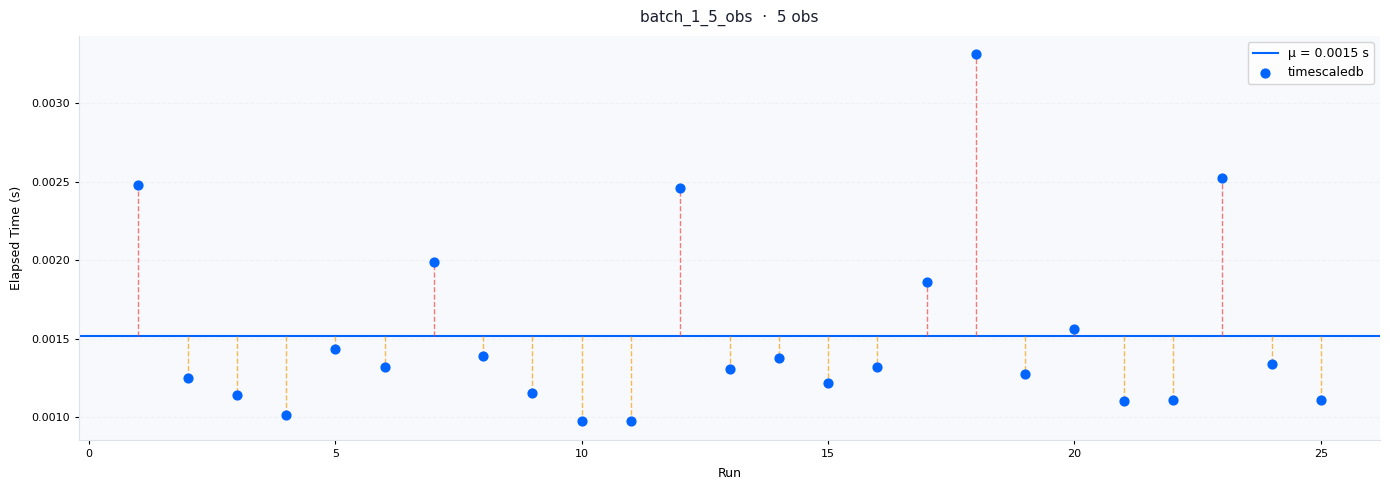

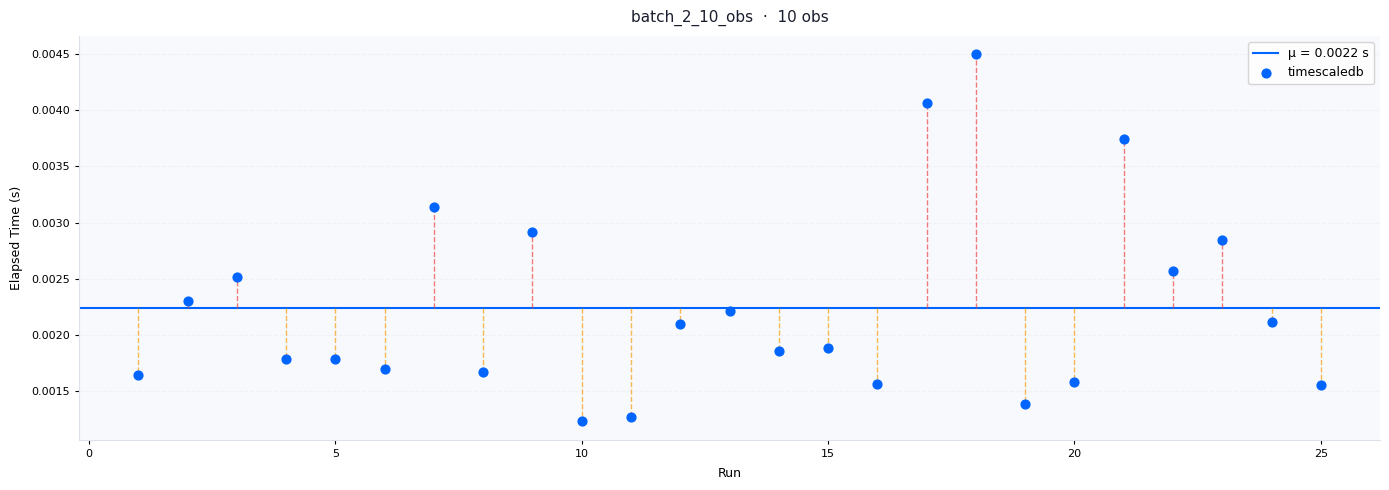

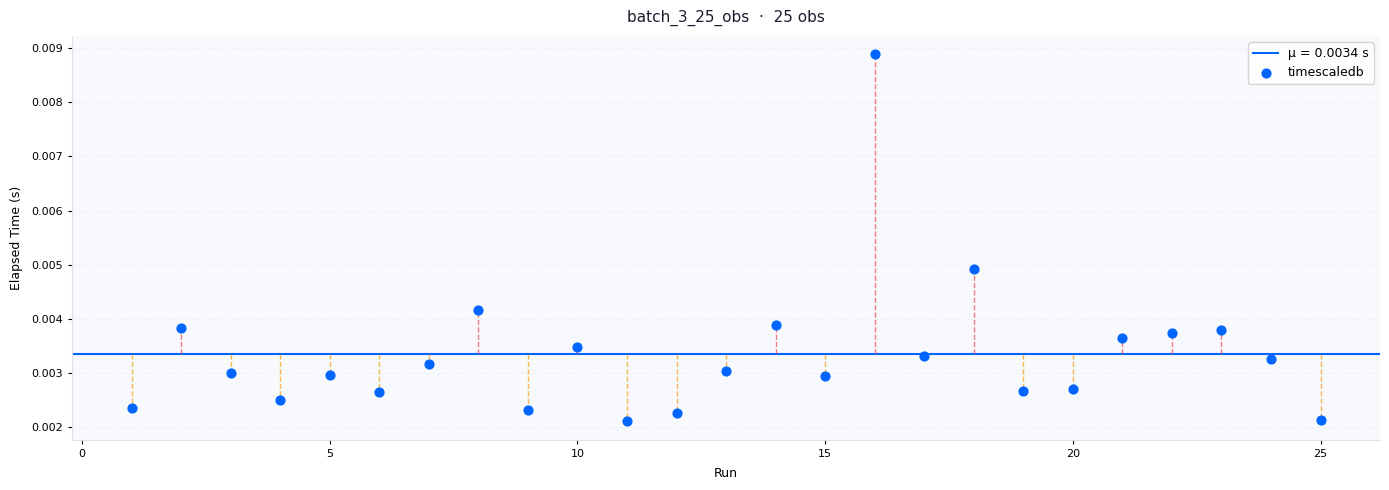

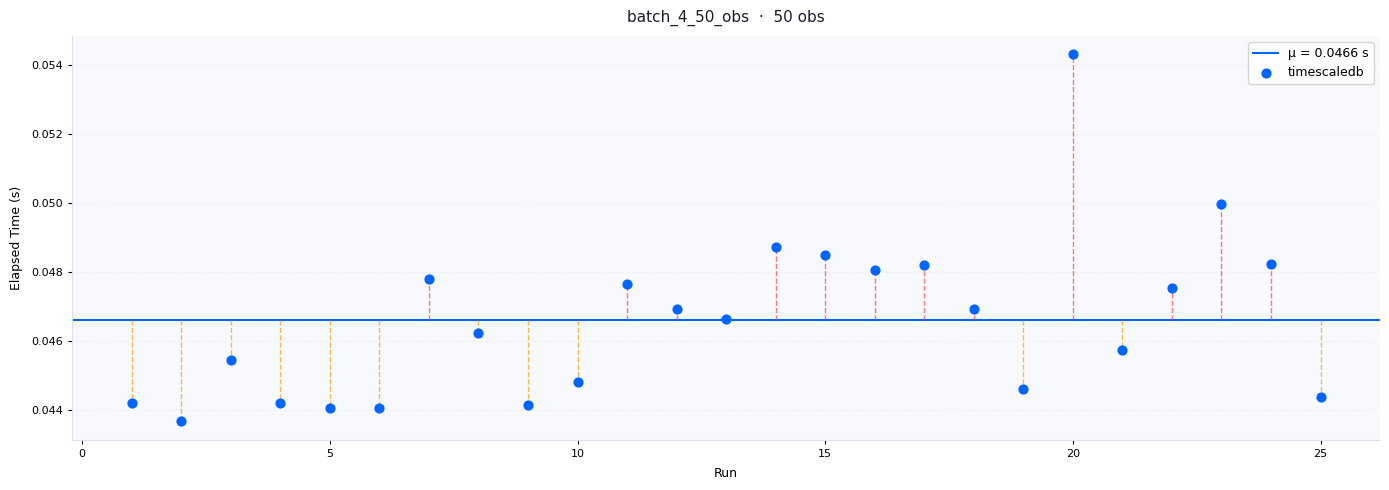

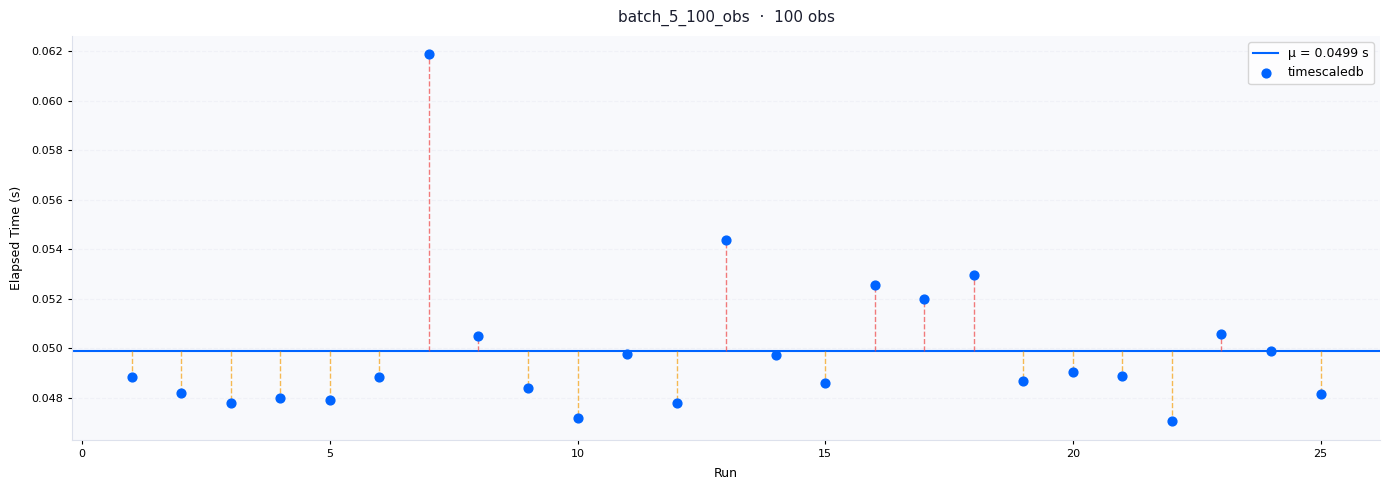

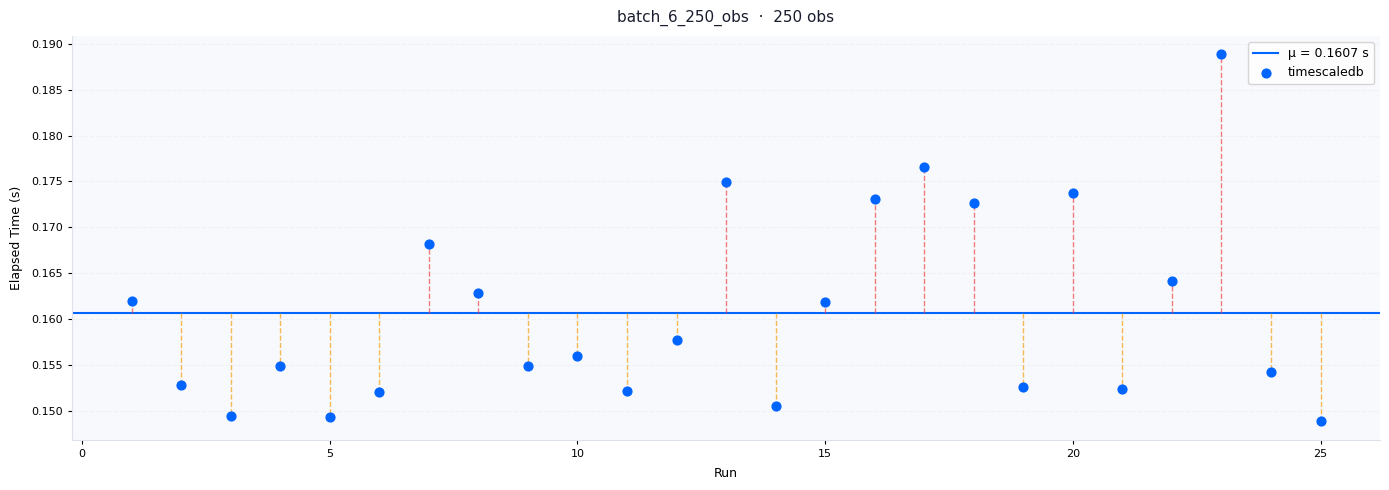

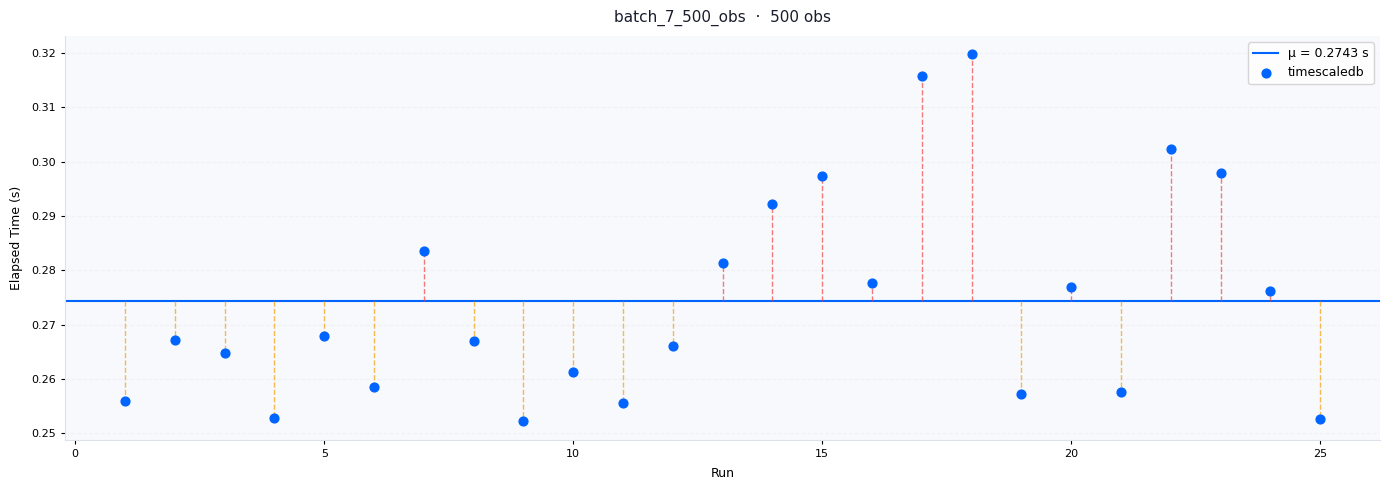

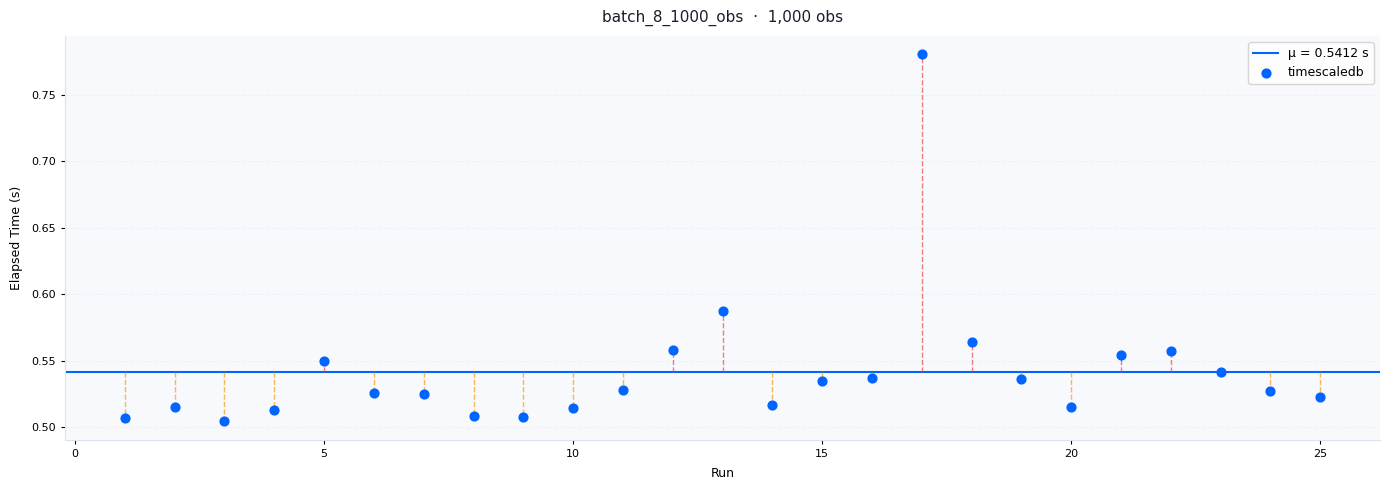

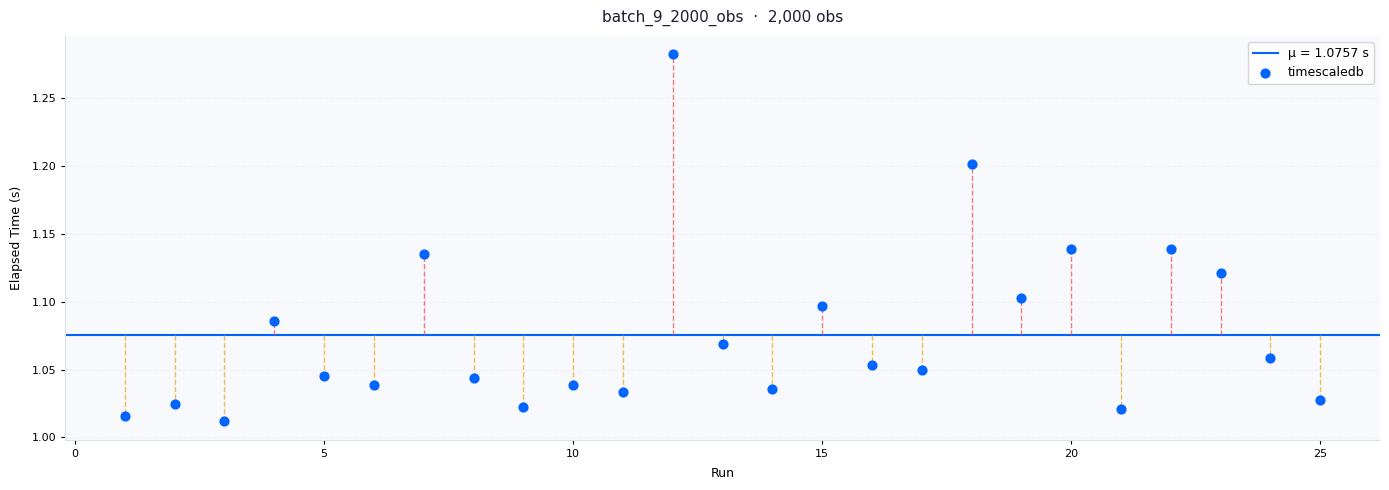

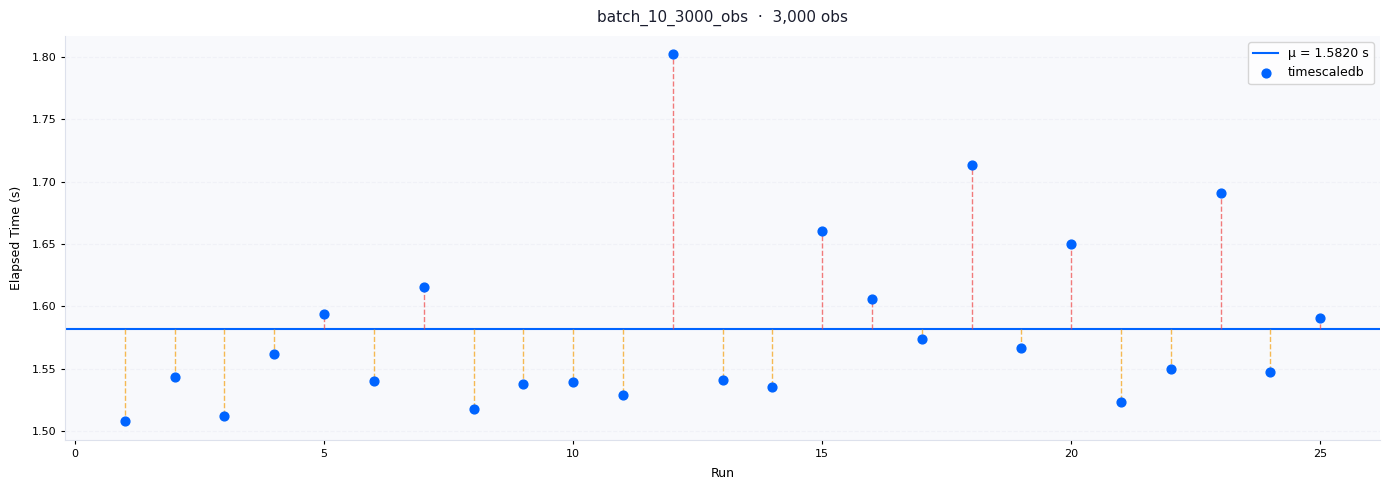

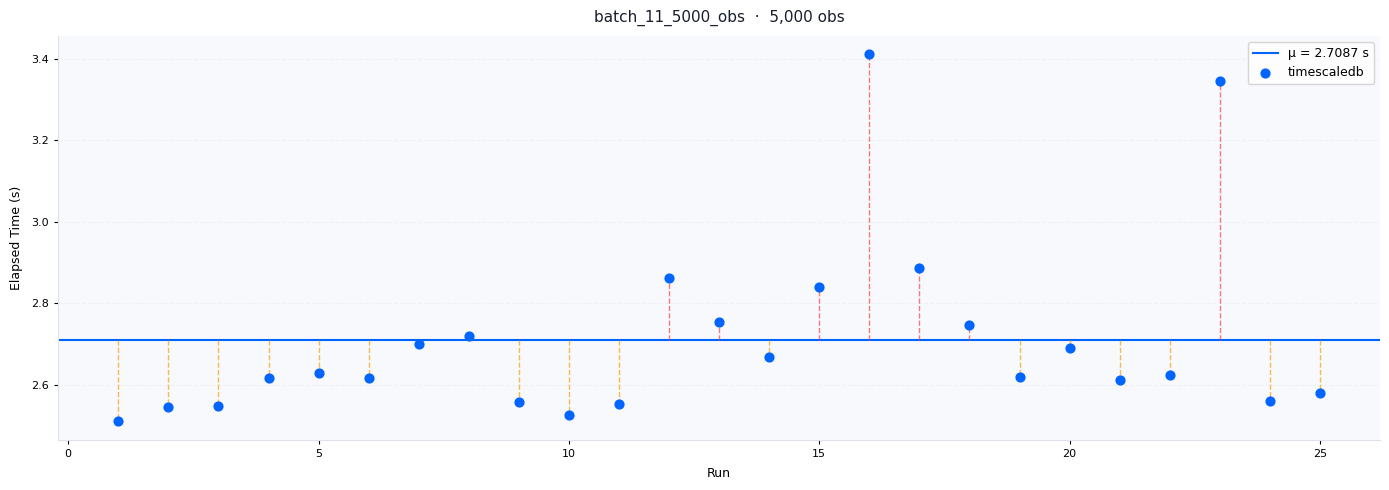

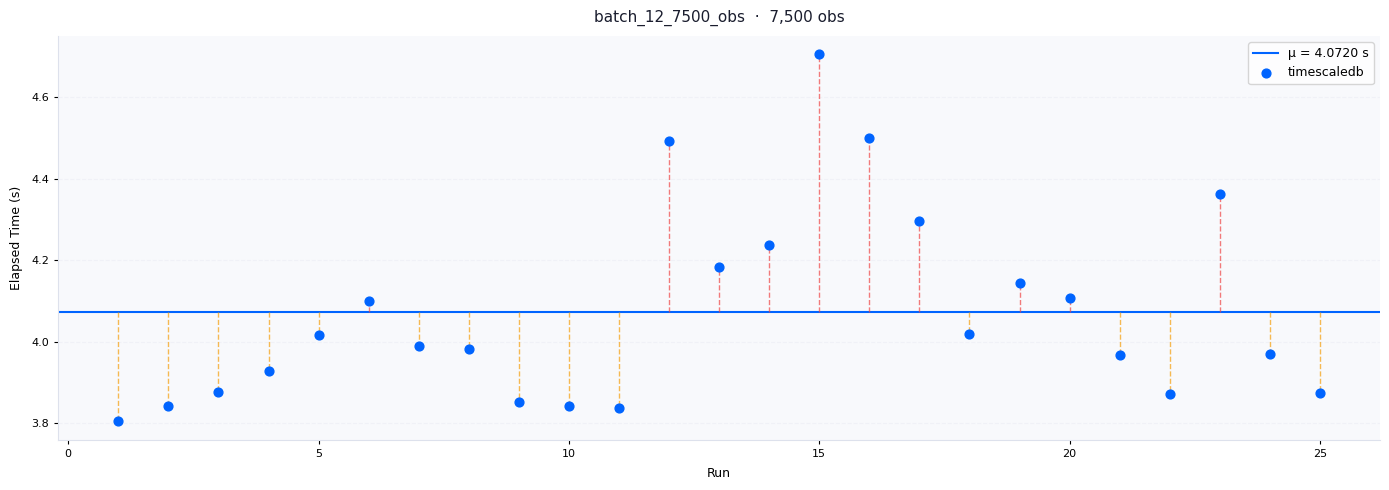

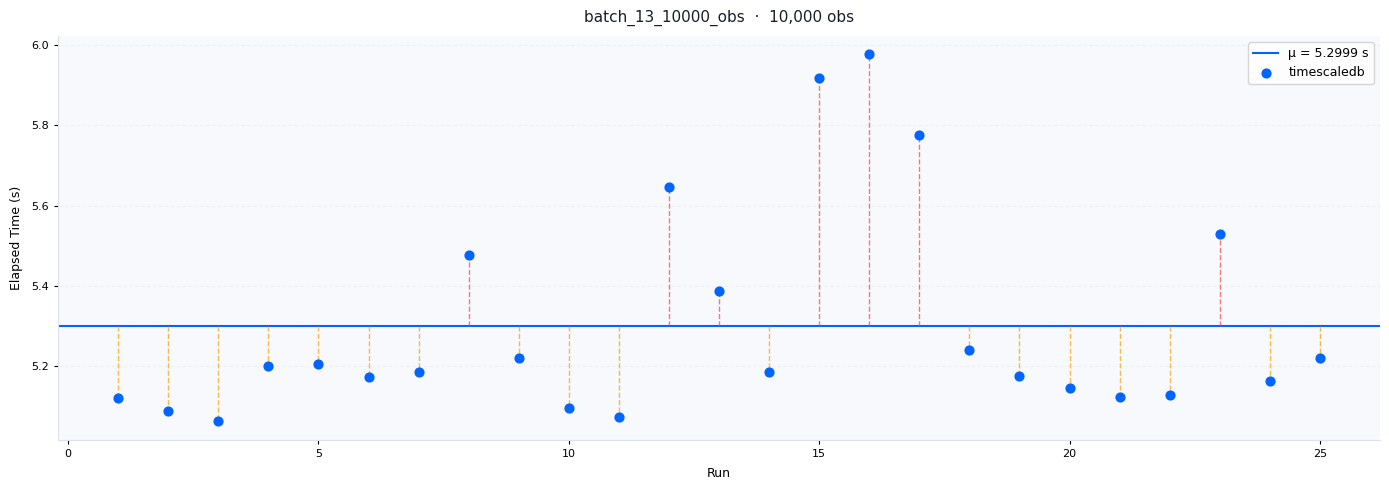

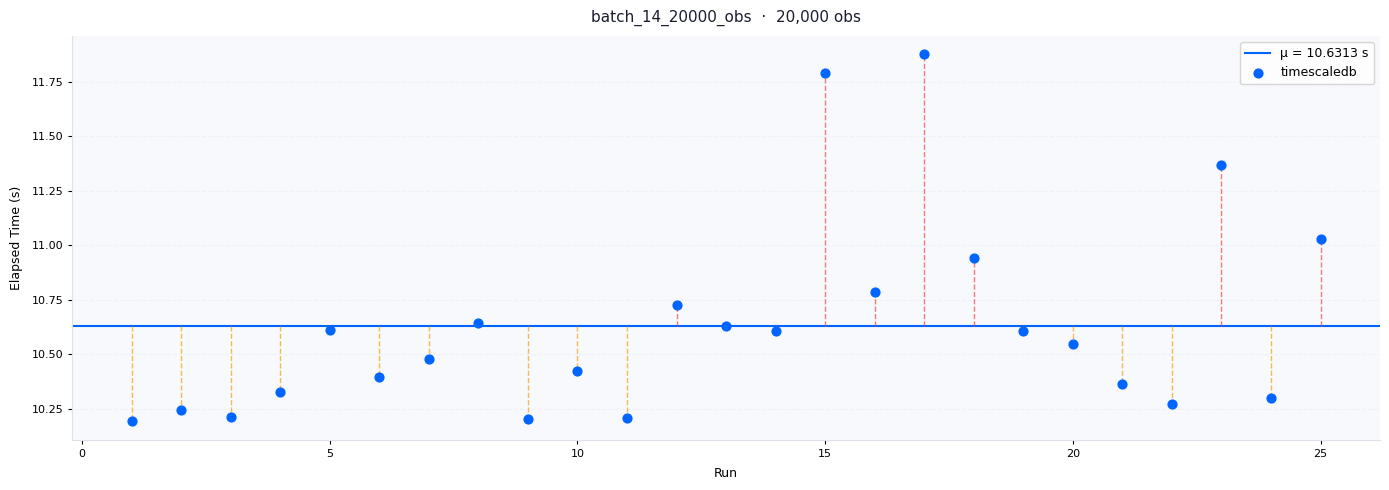

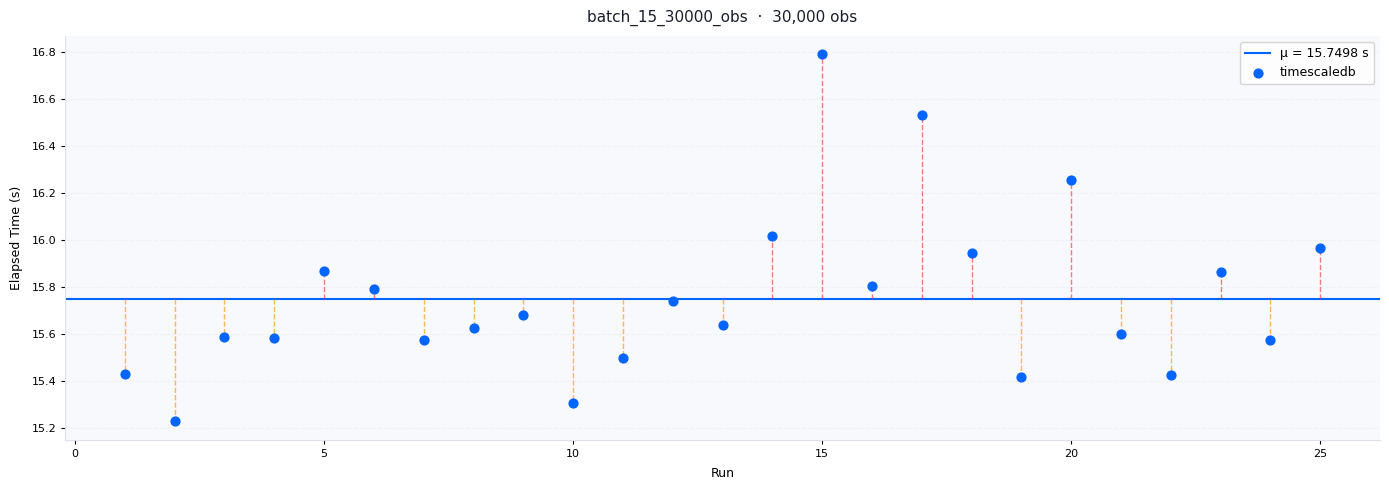

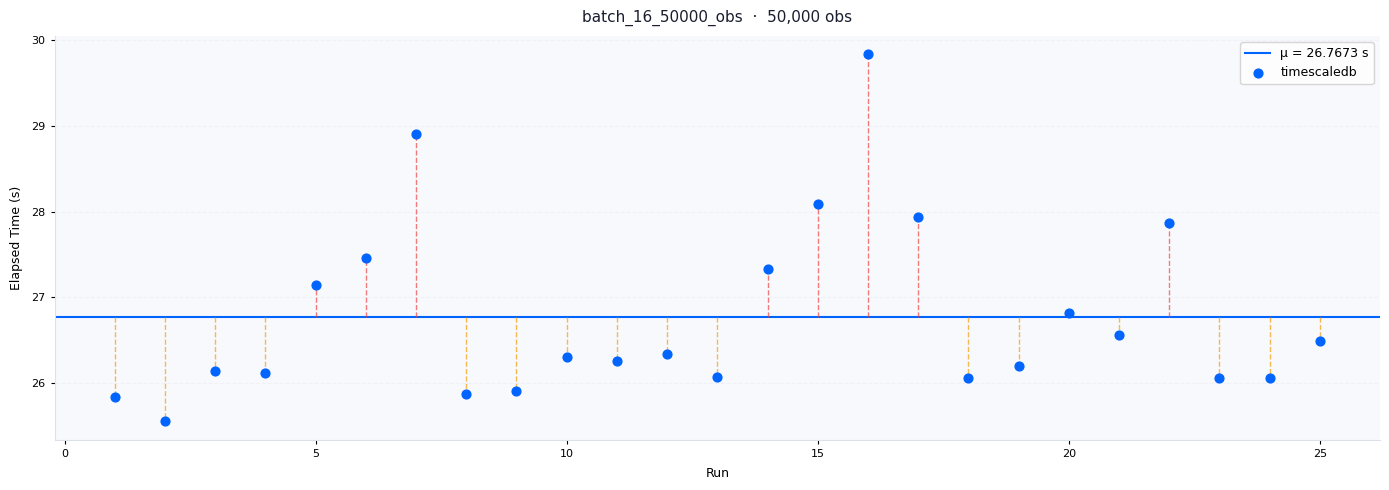

In [18]:
database = "timescaledb"

list_of_batch_ids = sorted({r.batch_id for r in db_results[database]})
print(f"{database} — batch ids: {list_of_batch_ids}")

for batch_id in list_of_batch_ids:
    batch = sorted(
        [r for r in db_results[database] if r.batch_id == batch_id],
        key=lambda r: r.created_at,
    )

    if not batch:
        continue

    run_numbers = list(range(1, len(batch) + 1))
    elapsed_s   = [r.elapsed_time_seconds for r in batch]
    mu          = np.mean(elapsed_s)
    color       = db_color[database]

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#f8f9fc')

    # mean line
    ax.axhline(mu, color=color, linewidth=1.5, linestyle='-',
               label=f'μ = {mu:.4f} s', zorder=2)

    # stems from each point to the mean
    for run, t in zip(run_numbers, elapsed_s):
        stem_color = '#ef4444' if t > mu else '#f59e0b'
        ax.plot([run, run], [mu, t], color=stem_color,
                linewidth=1.0, alpha=0.7, zorder=2,
                linestyle='--',)

    # points
    ax.scatter(run_numbers, elapsed_s,
               color=color, s=40, zorder=3, label=database)

    ax.set_title(
        f'{batch[0].dataset_name}  ·  {batch[0].record_count:,} obs',
        fontsize=11, pad=10, color='#1a1d2e',
    )
    ax.set_xlabel('Run', fontsize=9, labelpad=6)
    ax.set_ylabel('Elapsed Time (s)', fontsize=9, labelpad=6)
    ax.tick_params(axis='both', length=3, labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#dde1ec')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--')

    plt.tight_layout()
    plt.show()

## Residual Plot

One figure per dataset, all databases overlaid.  
Each database has its own mean line and stems.  
Red stems are runs above the mean, green stems are below the mean.

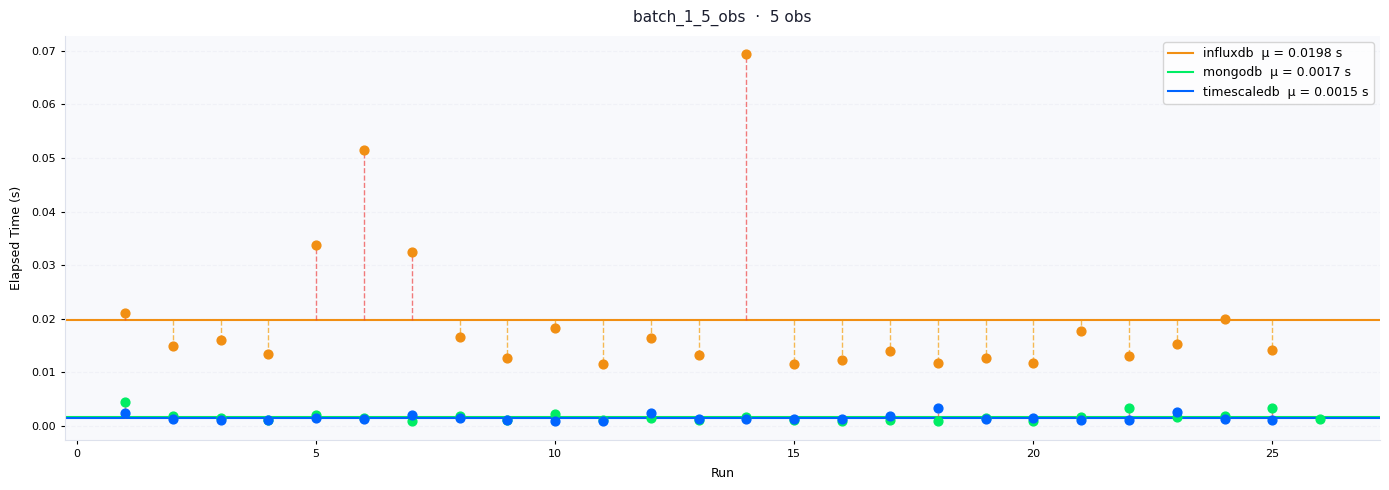

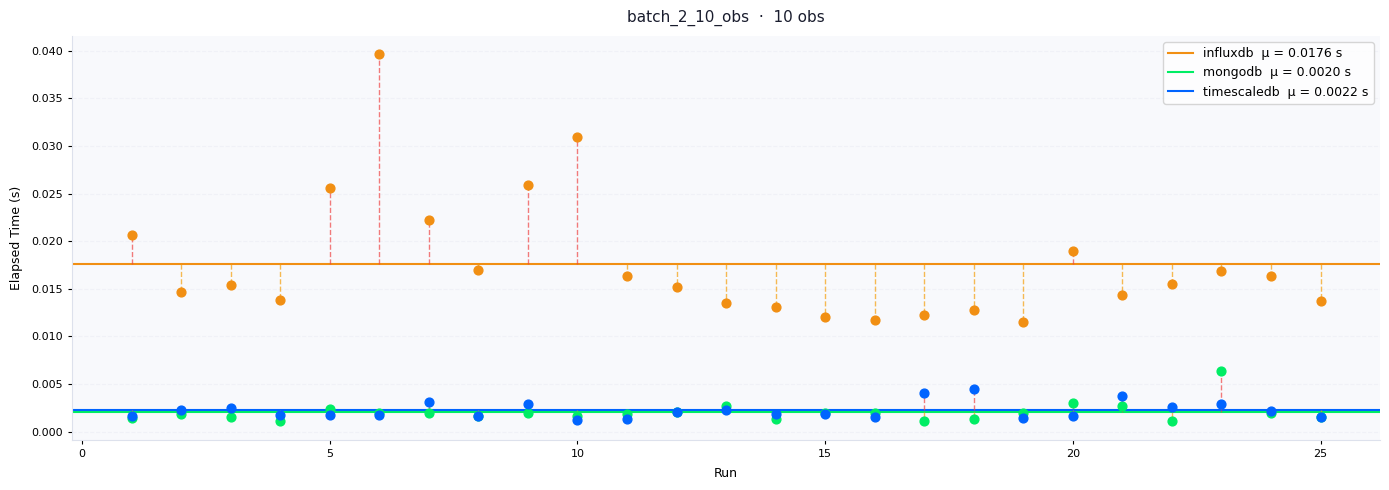

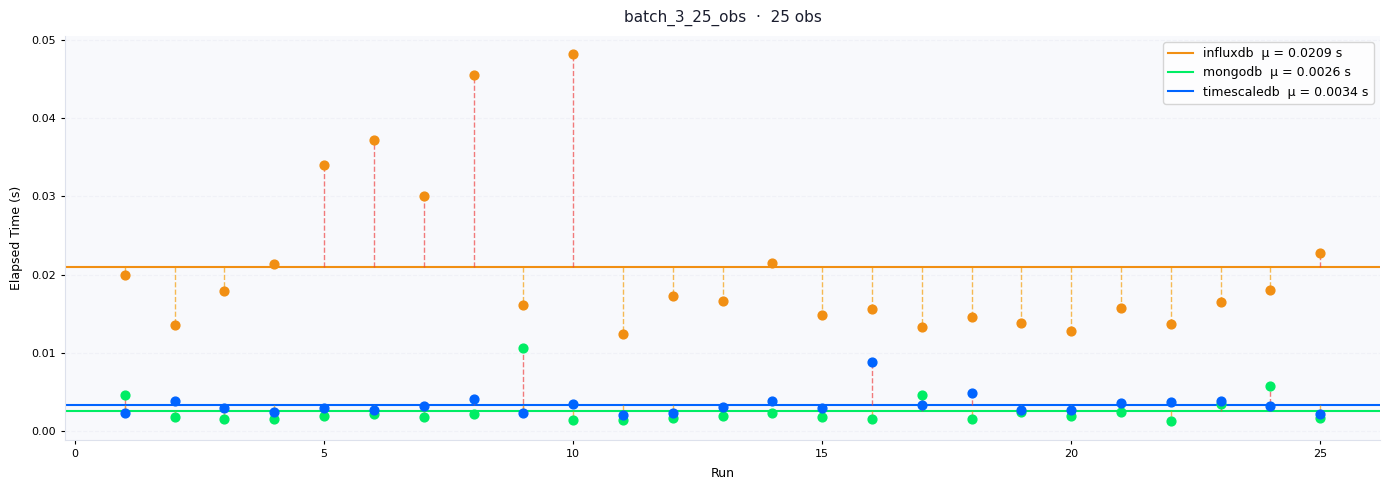

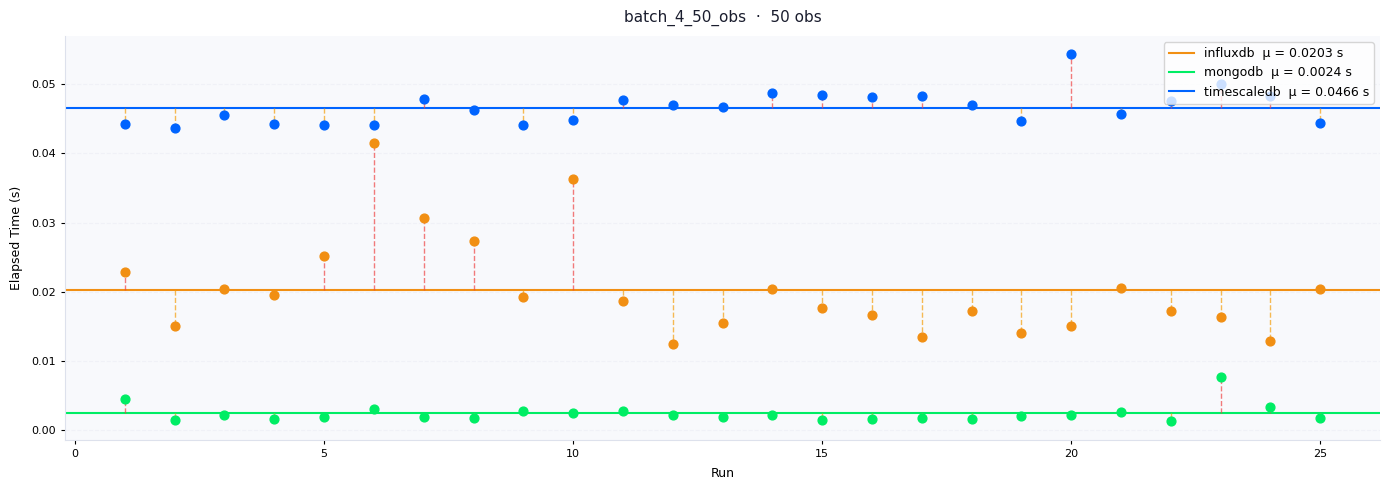

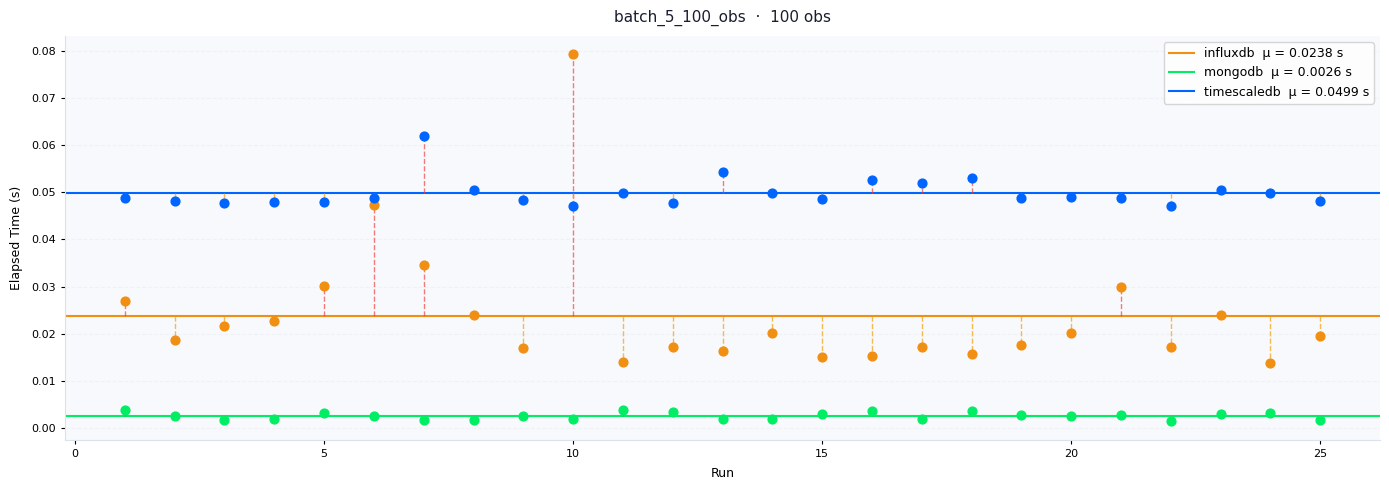

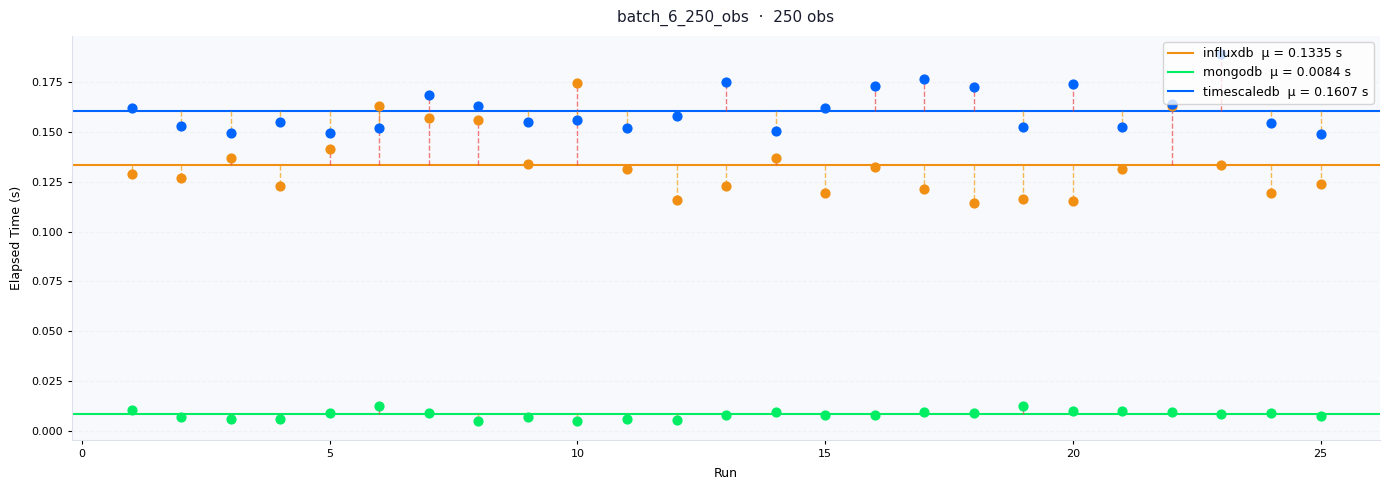

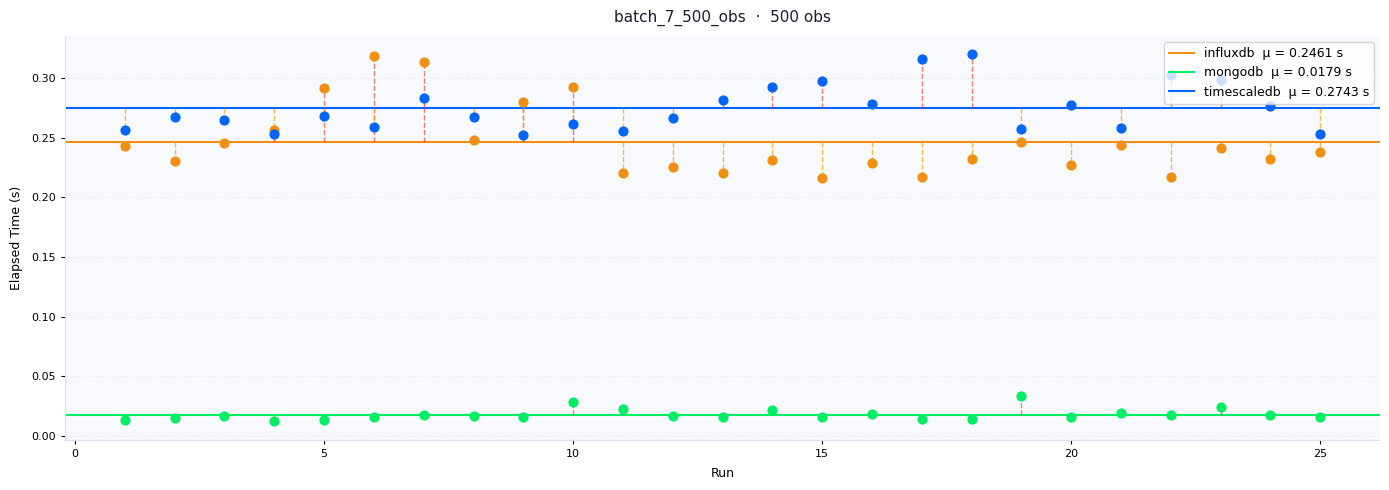

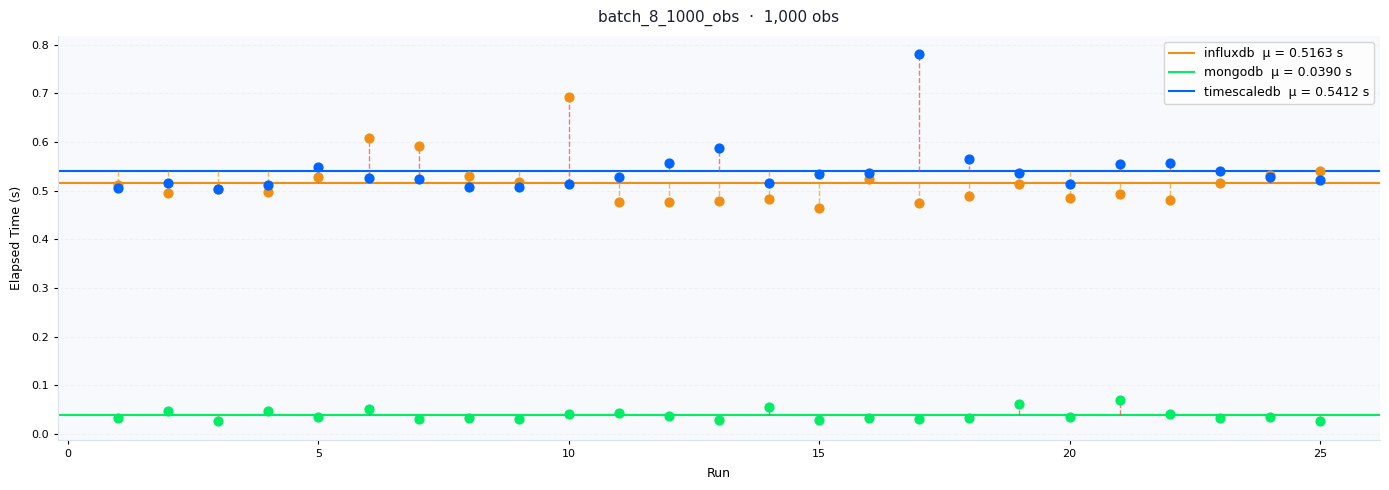

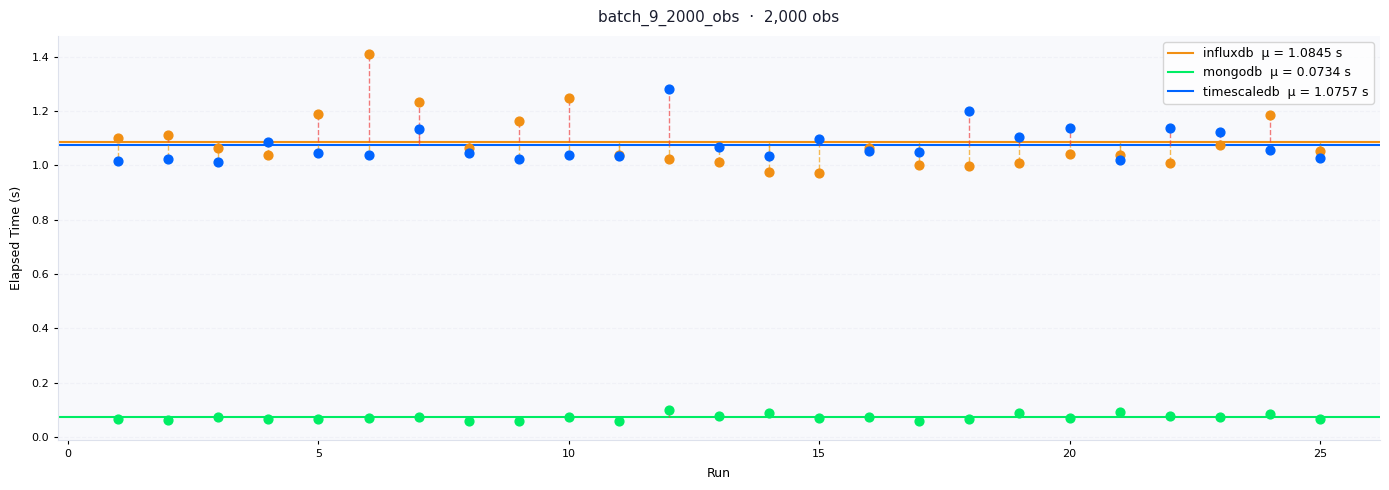

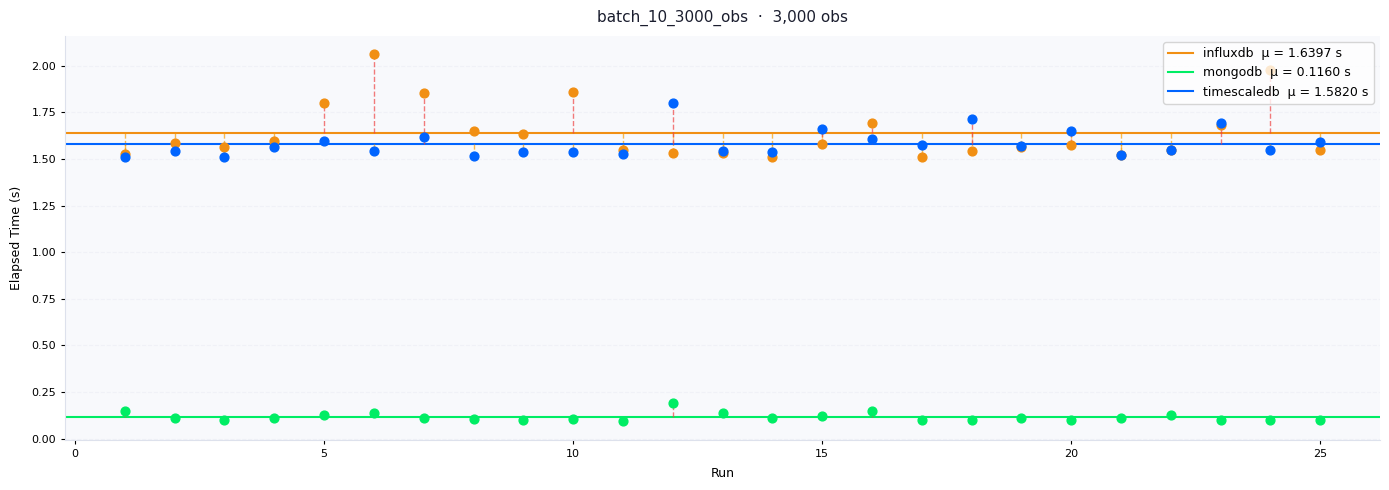

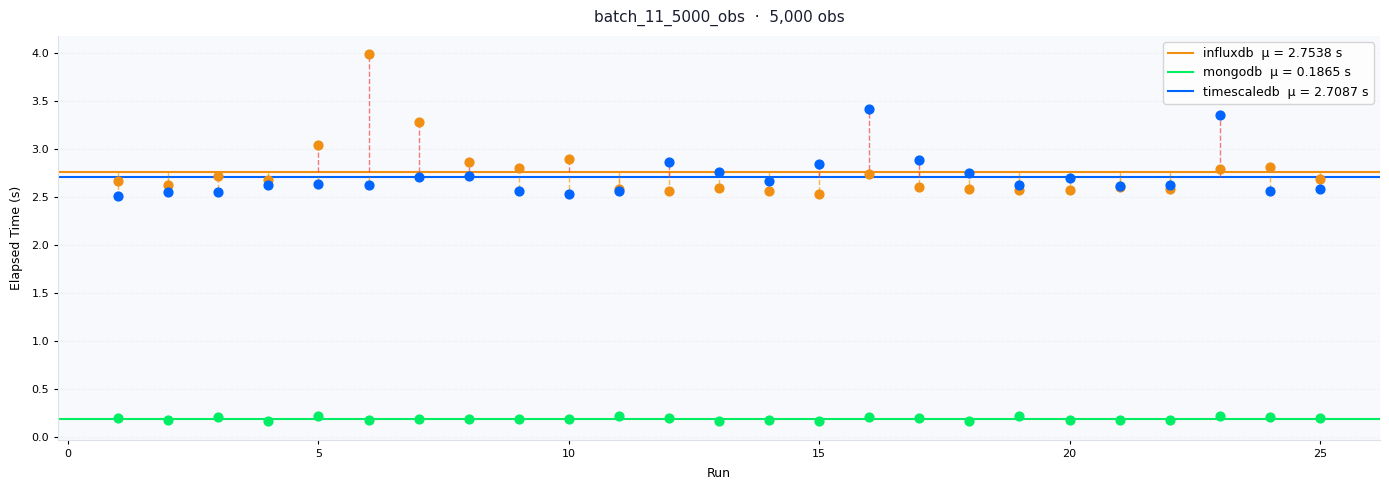

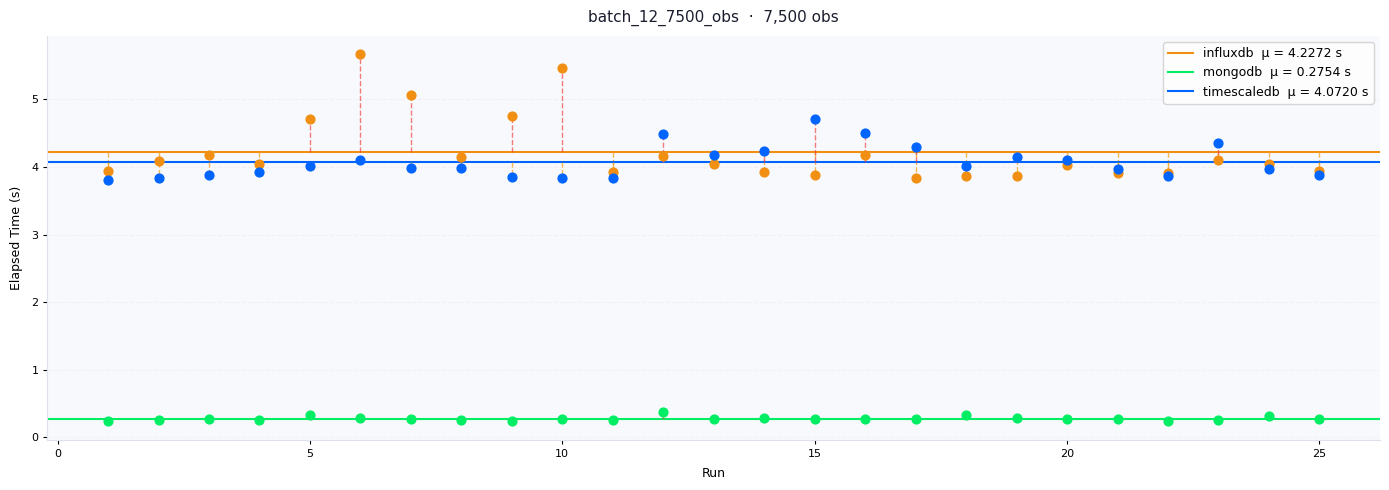

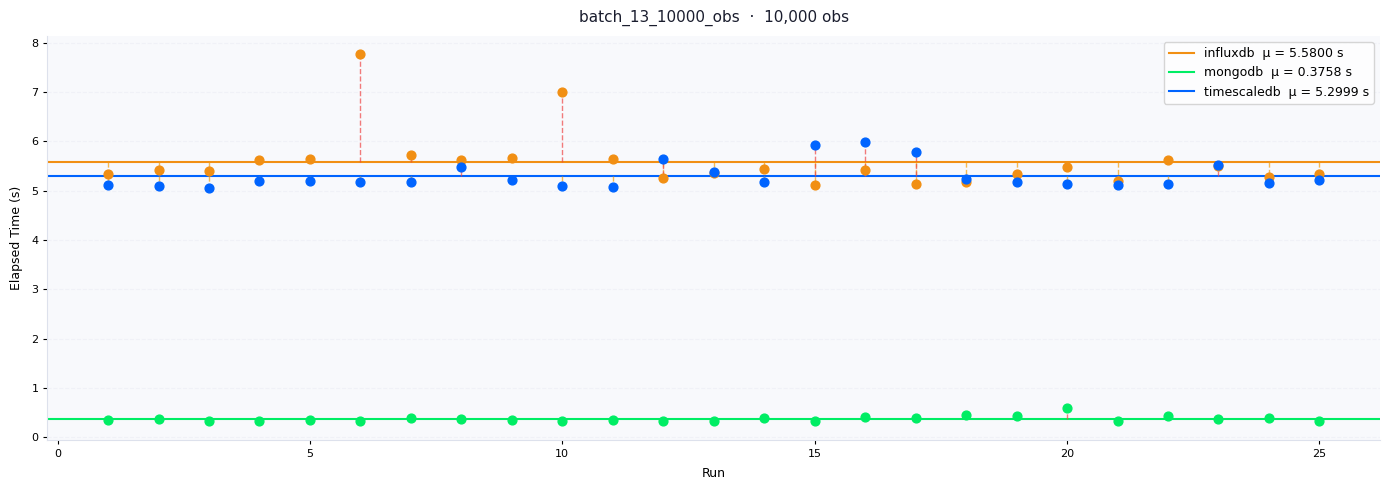

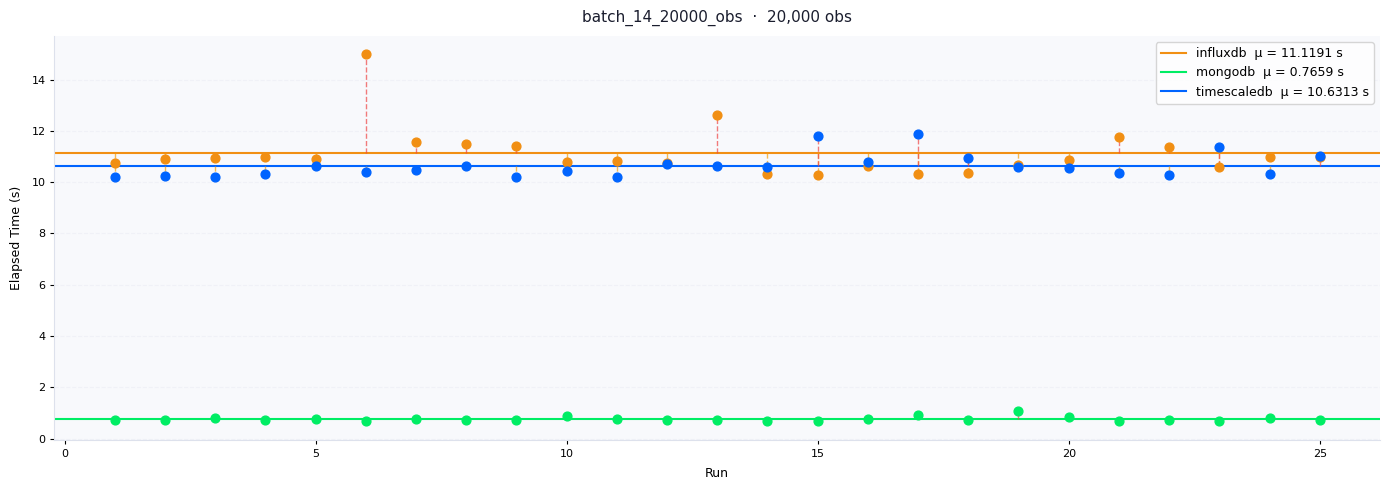

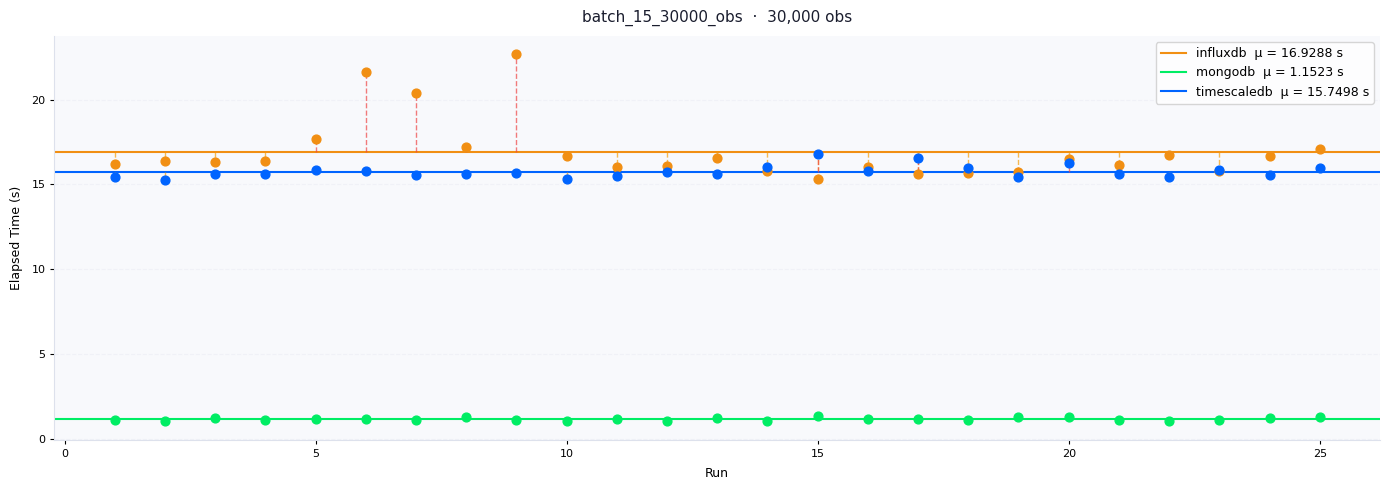

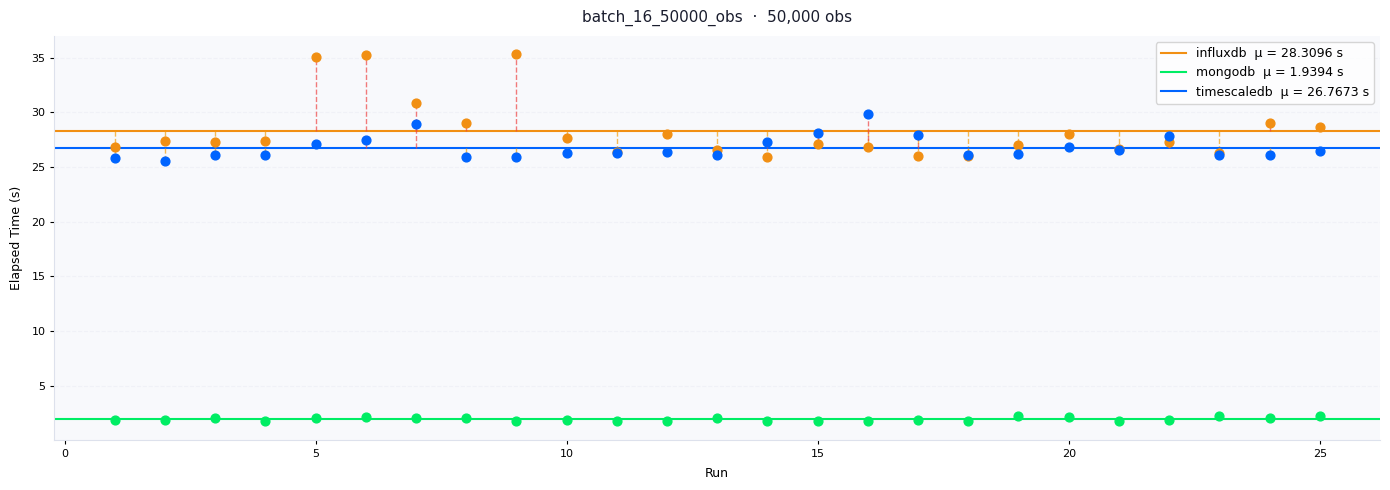

In [19]:
list_of_batch_ids = sorted({
    r.batch_id for db in db_systems for r in db_results[db]
})

for batch_id in list_of_batch_ids:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#f8f9fc')

    title_set = False

    for db in db_systems:
        batch = sorted(
            [r for r in db_results[db] if r.batch_id == batch_id],
            key=lambda r: r.created_at,
        )

        if not batch:
            continue

        run_numbers = list(range(1, len(batch) + 1))
        elapsed_s   = [r.elapsed_time_seconds for r in batch]
        mu          = np.mean(elapsed_s)
        color       = db_color[db]

        # mean line
        ax.axhline(mu, color=color, linewidth=1.5, linestyle='-',
                   label=f'{db}  μ = {mu:.4f} s', zorder=2)

        # stems
        for run, t in zip(run_numbers, elapsed_s):
            stem_color = '#ef4444' if t > mu else '#f59e0b'
            ax.plot([run, run], [mu, t], color=stem_color,
                    linewidth=1.0, alpha=0.7, linestyle='--', zorder=2)

        # points
        ax.scatter(run_numbers, elapsed_s,
                   color=color, s=40, zorder=3)

        if not title_set:
            ax.set_title(
                f'{batch[0].dataset_name}  ·  {batch[0].record_count:,} obs',
                fontsize=11, pad=10, color='#1a1d2e',
            )
            title_set = True

    ax.set_xlabel('Run', fontsize=9, labelpad=6)
    ax.set_ylabel('Elapsed Time (s)', fontsize=9, labelpad=6)
    ax.tick_params(axis='both', length=3, labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#dde1ec')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--')

    plt.tight_layout()
    plt.show()

## Summary Table

One row per `database_system × dataset`.  
Columns: record count, data size, mean elapsed time, std, coefficient of variation (CV%), mean throughput.

In [20]:

rows = []
for db in db_systems:
    for batch_id in sorted({r.batch_id for r in db_results[db]}):
        batch    = [r for r in db_results[db] if r.batch_id == batch_id]
        elapsed  = [r.elapsed_time_seconds   for r in batch]
        tput_obs = [r.throughput_obs_per_sec for r in batch]
        tput_mb  = [r.throughput_mb_per_sec  for r in batch]
        mu       = np.mean(elapsed)
        std      = np.std(elapsed)

        rows.append({
            'database_system':       db,
            'dataset_name':          batch[0].dataset_name,
            'record_count':          batch[0].record_count,
            'data_size_mb':          round(batch[0].data_size_mb,    3),
            'n_runs':                len(batch),
            'mean_elapsed_s':        round(mu,                       6),
            'std_elapsed_s':         round(std,                      6),
            'cv_pct':                round((std / mu) * 100,         2),
            'mean_throughput_obs_s': round(np.mean(tput_obs),        2),
            'mean_throughput_mb_s':  round(np.mean(tput_mb),         4),
        })

summary_df = (
    pd.DataFrame(rows)
    .set_index(['database_system', 'dataset_name'])
)

summary_df

record_count  data_size_mb  n_runs  \
database_system dataset_name                                             
influxdb        batch_1_5_obs                  5         0.001      25   
                batch_2_10_obs                10         0.002      25   
                batch_3_25_obs                25         0.005      25   
                batch_4_50_obs                50         0.010      25   
                batch_5_100_obs              100         0.020      25   
                batch_6_250_obs              250         0.051      25   
                batch_7_500_obs              500         0.102      25   
                batch_8_1000_obs            1000         0.204      25   
                batch_9_2000_obs            2000         0.408      25   
                batch_10_3000_obs           3000         0.612      25   
                batch_11_5000_obs           5000         1.020      25   
                batch_12_7500_obs           7500         1.530      25   
                batch_13_10000_obs         10000         2.039      25   
                batch_14_20000_obs         20000         4.079      25   
                batch_15_30000_obs         30000         6.118      25   
                batch_16_50000_obs         50000        10.196      25   
mongodb         batch_1_5_obs                  5         0.001      26   
                batch_2_10_obs                10         0.002      25   
                batch_3_25_obs                25         0.005      25   
                batch_4_50_obs                50         0.010      25   
                batch_5_100_obs              100         0.020      25   
                batch_6_250_obs              250         0.051      25   
                batch_7_500_obs              500         0.102      25   
                batch_8_1000_obs            1000         0.204      25   
                batch_9_2000_obs            2000         0.408      25   
                batch_10_3000_obs           3000         0.612      25   
                batch_11_5000_obs           5000         1.020      25   
                batch_12_7500_obs           7500         1.530      25   
                batch_13_10000_obs         10000         2.039      25   
                batch_14_20000_obs         20000         4.079      25   
                batch_15_30000_obs         30000         6.118      25   
                batch_16_50000_obs         50000        10.196      25   
timescaledb     batch_1_5_obs                  5         0.001      25   
                batch_2_10_obs                10         0.002      25   
                batch_3_25_obs                25         0.005      25   
                batch_4_50_obs                50         0.010      25   
                batch_5_100_obs              100         0.020      25   
                batch_6_250_obs              250         0.051      25   
                batch_7_500_obs              500         0.102      25   
                batch_8_1000_obs            1000         0.204      25   
                batch_9_2000_obs            2000         0.408      25   
                batch_10_3000_obs           3000         0.612      25   
                batch_11_5000_obs           5000         1.020      25   
                batch_12_7500_obs           7500         1.530      25   
                batch_13_10000_obs         10000         2.039      25   
                batch_14_20000_obs         20000         4.079      25   
                batch_15_30000_obs         30000         6.118      25   
                batch_16_50000_obs         50000        10.196      25   

                                    mean_elapsed_s  std_elapsed_s  cv_pct  \
database_system dataset_name                                                
influxdb        batch_1_5_obs             0.019821       0.013451   67.87   
                batch_2_10_obs            0.017599       0.006602   37.51   
                batch_3_25_

## Normal Distribution

In [21]:
from scipy.stats import norm

### Per Database

One figure per `database_system`,  one per dataset.  
Fitted Gaussian showing μ and σ for each dataset.

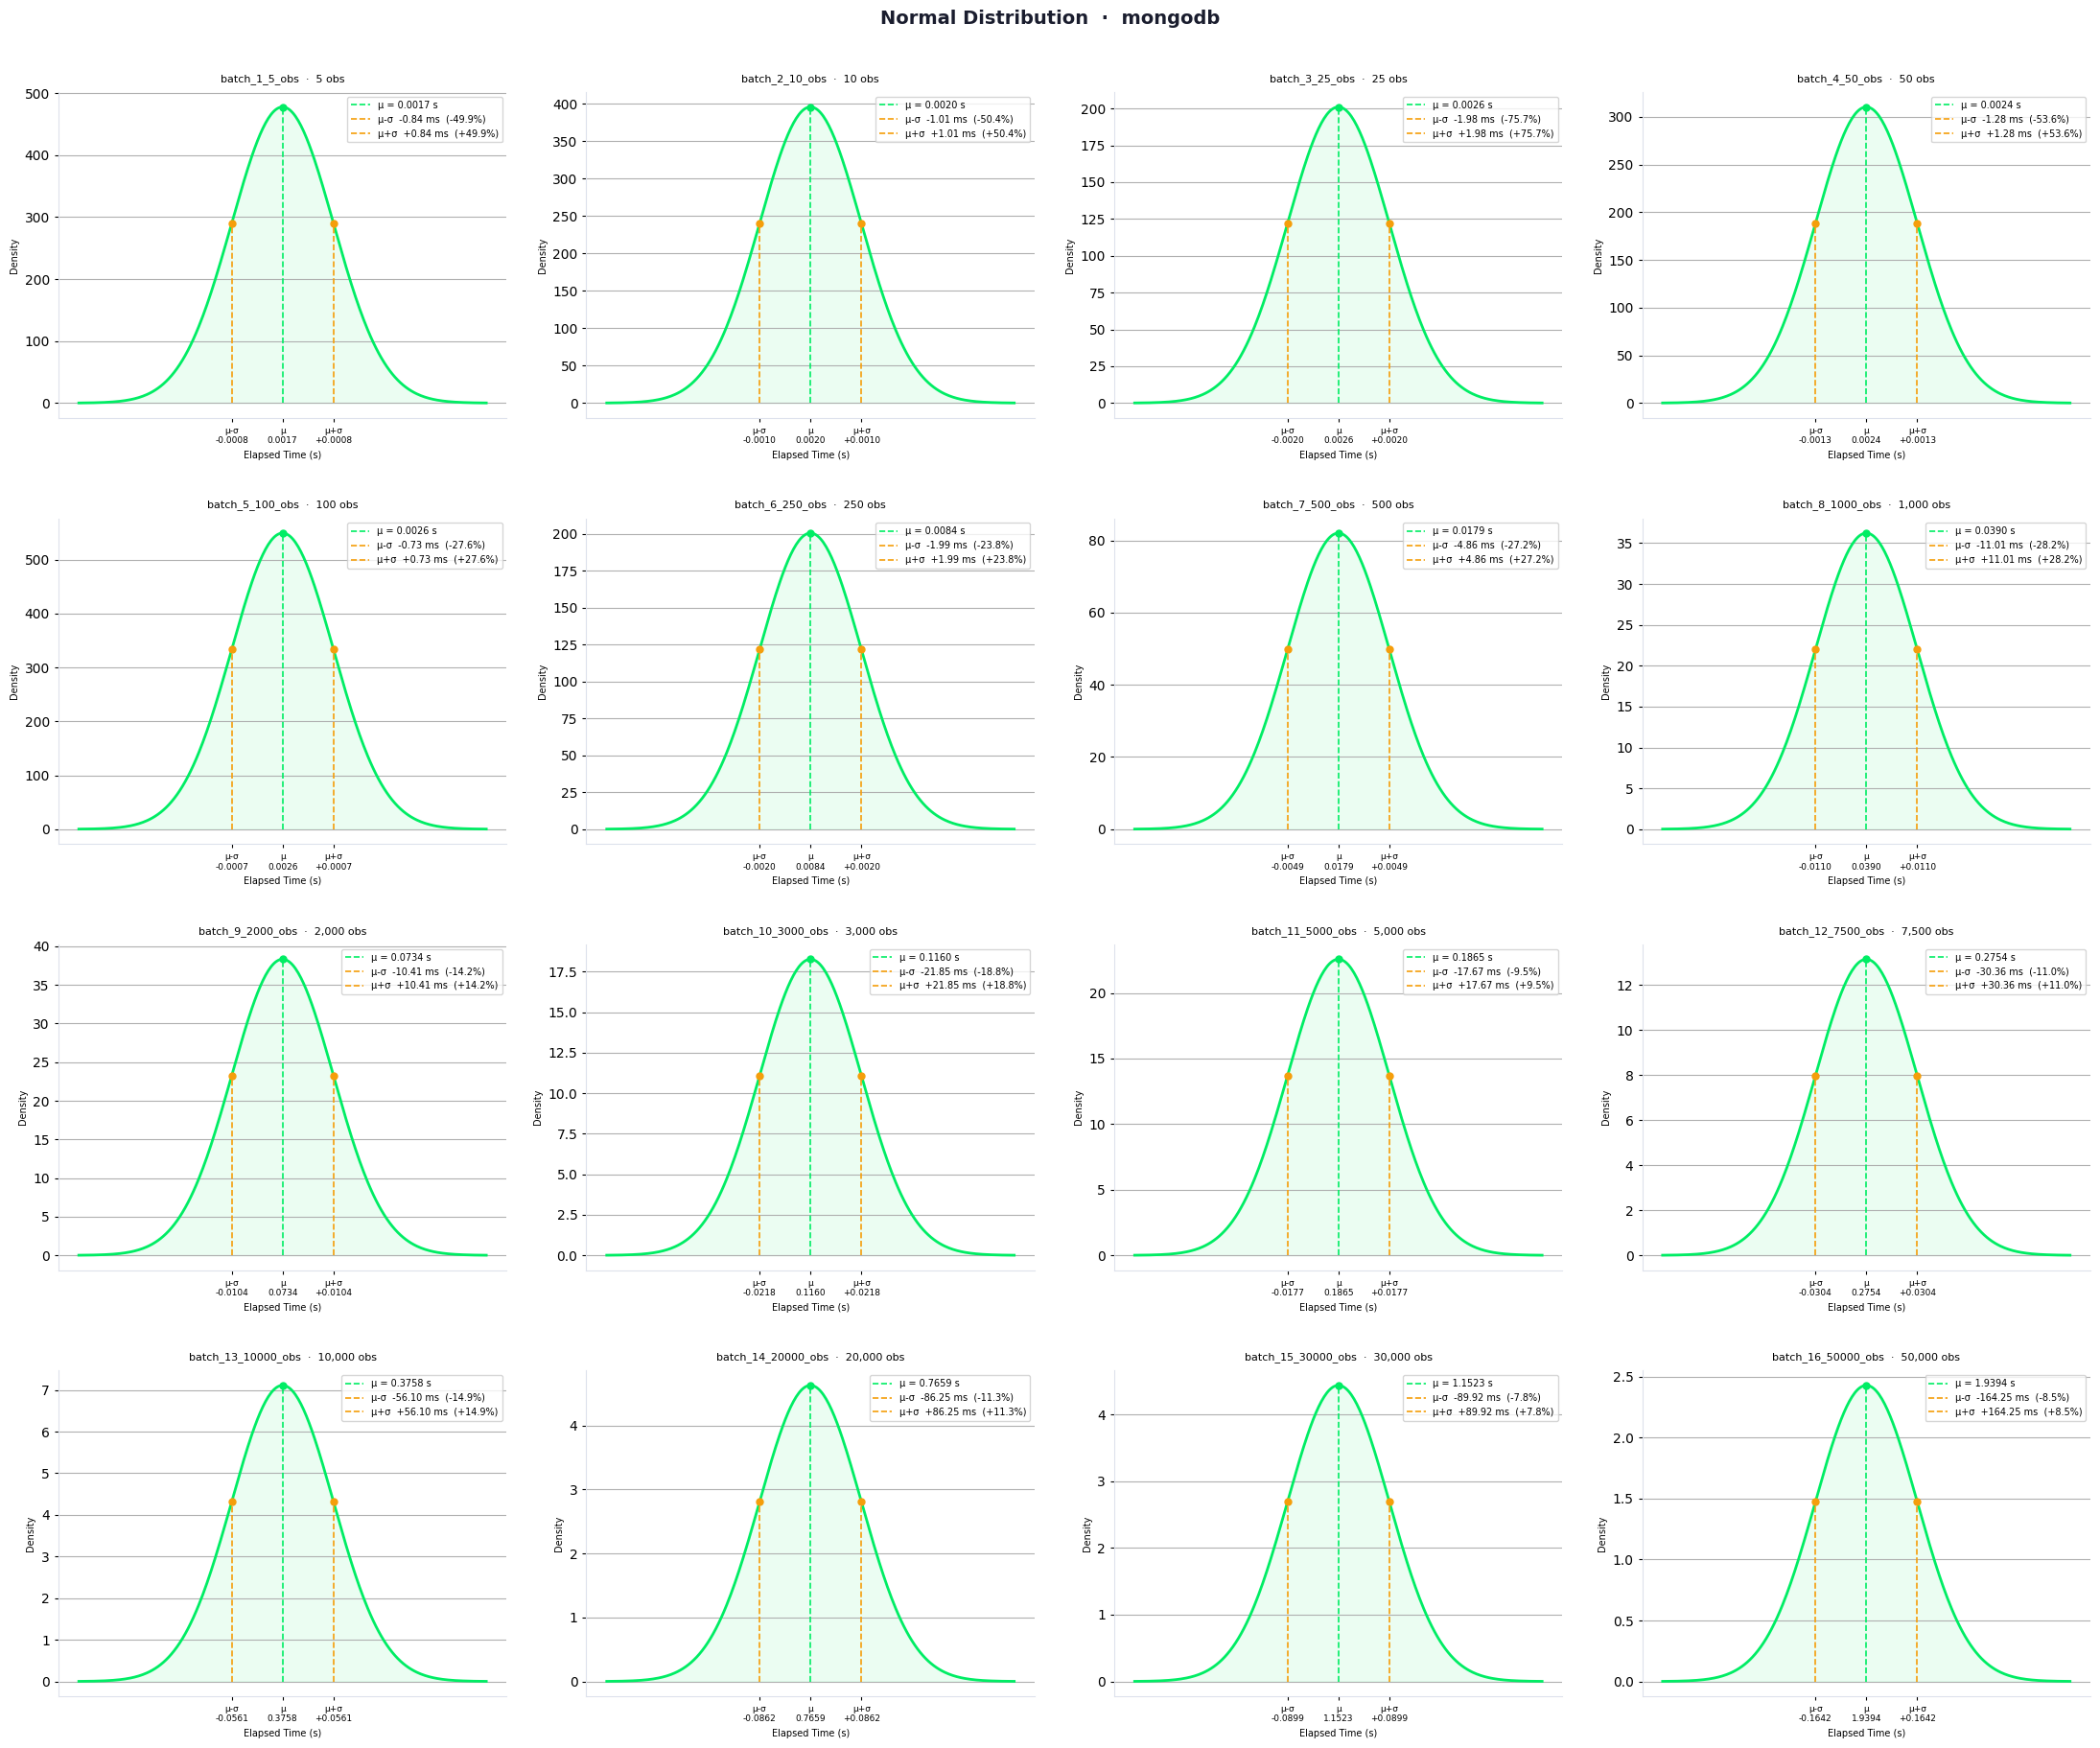

In [22]:
database = "mongodb"

results_db = db_results[database]
color      = db_color[database]

list_of_batch_ids = sorted({r.batch_id for r in results_db})
n              = len(list_of_batch_ids)
ncols          = 4
nrows          = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 4.5))
fig.patch.set_facecolor('#ffffff')
axes = axes.flatten()

for i, batch_id in enumerate(list_of_batch_ids):
    ax    = axes[i]
    batch = sorted(
        [r for r in results_db if r.batch_id == batch_id],
        key=lambda r: r.created_at,
    )

    if len(batch) < 2:
        ax.set_title(f'Batch {batch_id} — no data', fontsize=9)
        ax.axis('off')
        continue

    elapsed  = [r.elapsed_time_seconds for r in batch]
    mu, std  = norm.fit(elapsed)
    std_ms   = std * 1000
    std_pct  = (std / mu) * 100

    x = np.linspace(mu - 4 * std, mu + 4 * std, 300)
    p = norm.pdf(x, mu, std)

    ax.fill_between(x, p, alpha=0.08, color=color)
    ax.plot(x, p, color=color, linewidth=2)

    for val, line_color, label in [
        (mu,       color,     f'μ = {mu:.4f} s'),
        (mu - std, '#f59e0b', f'μ-σ  -{std_ms:.2f} ms  (-{std_pct:.1f}%)'),
        (mu + std, '#f59e0b', f'μ+σ  +{std_ms:.2f} ms  (+{std_pct:.1f}%)'),
    ]:
        y_val = norm.pdf(val, mu, std)
        ax.plot([val, val], [0, y_val], color=line_color,
                linestyle='--', linewidth=1.2, label=label)
        ax.plot(val, y_val, 'o', color=line_color, markersize=5, zorder=5)

    ax.set_title(
        f'{batch[0].dataset_name}  ·  {batch[0].record_count:,} obs',
        fontsize=8, pad=8,
    )
    ax.set_xlabel('Elapsed Time (s)', fontsize=7, labelpad=4)
    ax.set_ylabel('Density', fontsize=7, labelpad=4)
    ax.set_xticks([mu - std, mu, mu + std])
    ax.set_xticklabels(
        [f'μ-σ\n-{std:.4f}', f'μ\n{mu:.4f}', f'μ+σ\n+{std:.4f}'],
        fontsize=6.5,
    )
    ax.tick_params(axis='both', length=3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#dde1ec')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, axis='y')

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(
    f'Normal Distribution  ·  {database}',
    fontsize=14, fontweight='bold', color='#1a1d2e', y=1.01,
)
plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

### All Databases Overlaid

One figure per dataset, all databases overlaid.  
Each database has its own fitted Gaussian in its brand color.

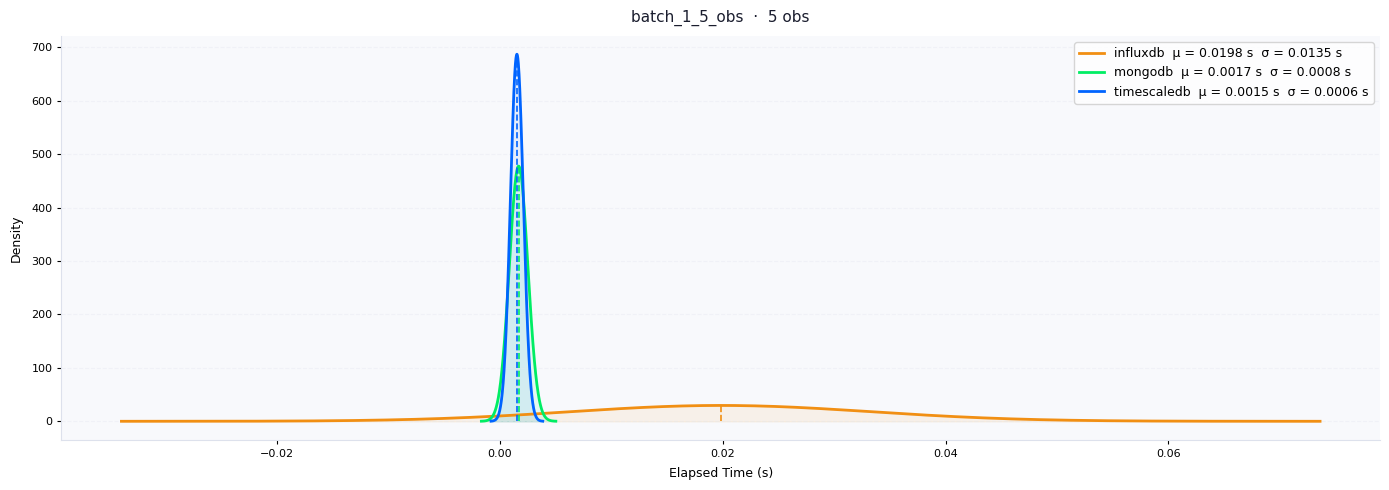

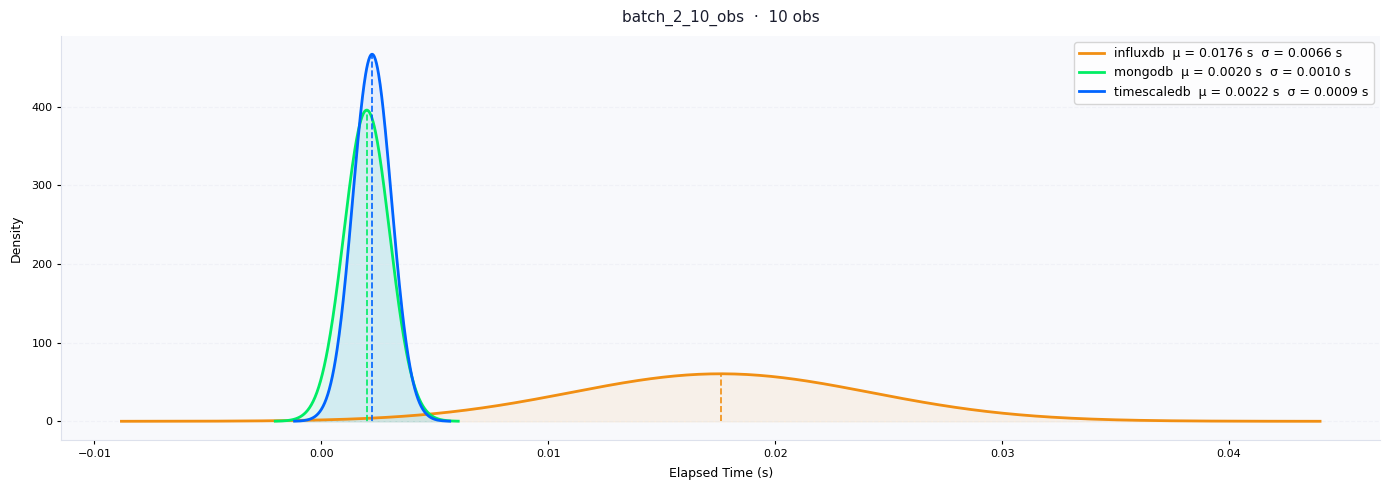

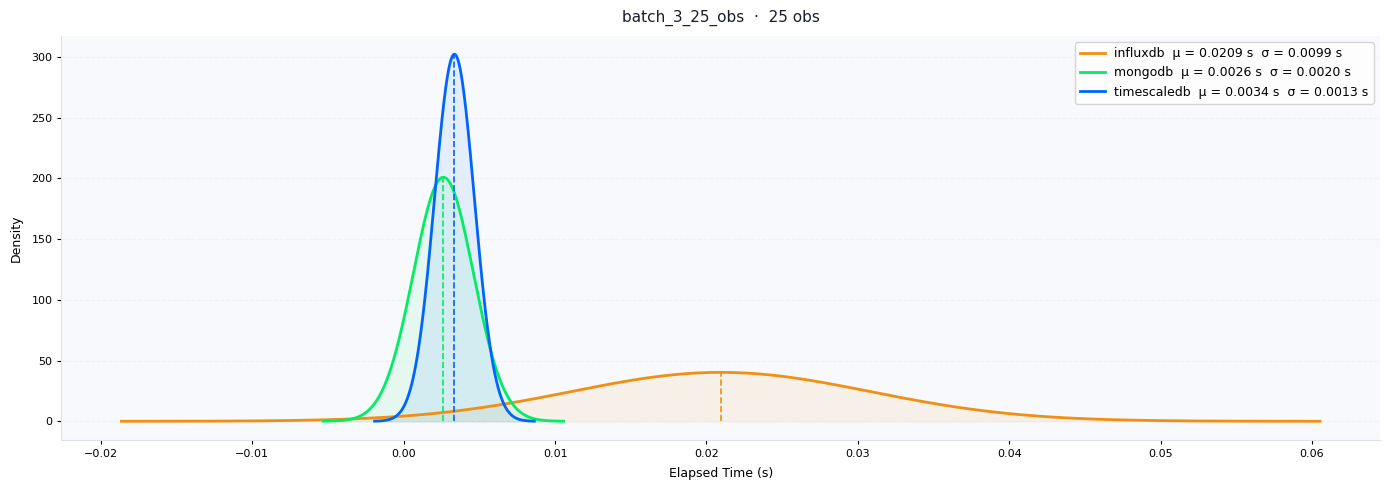

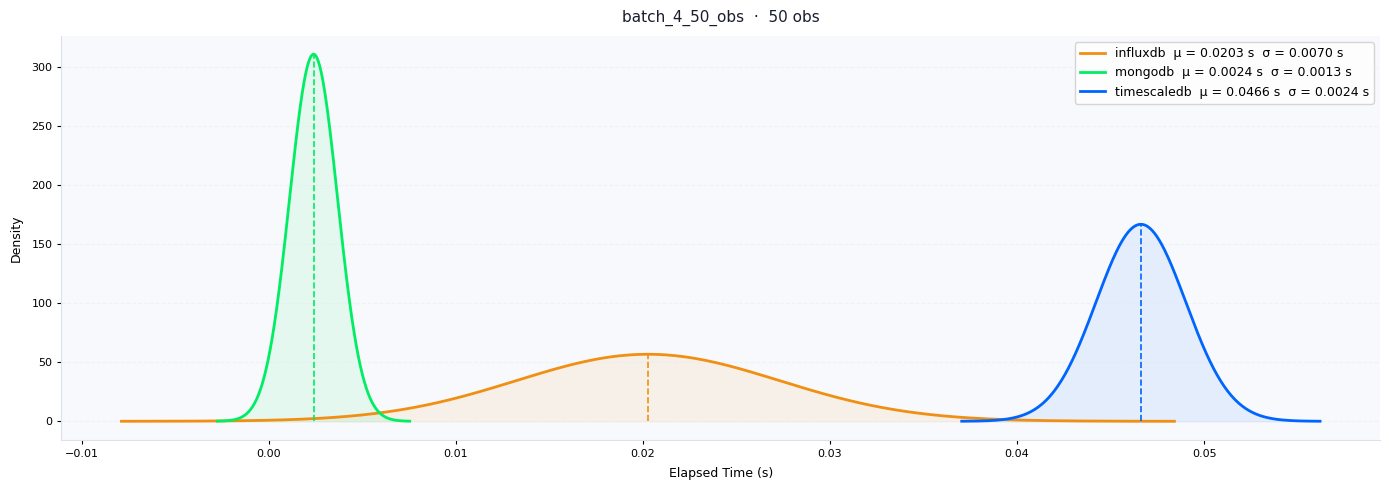

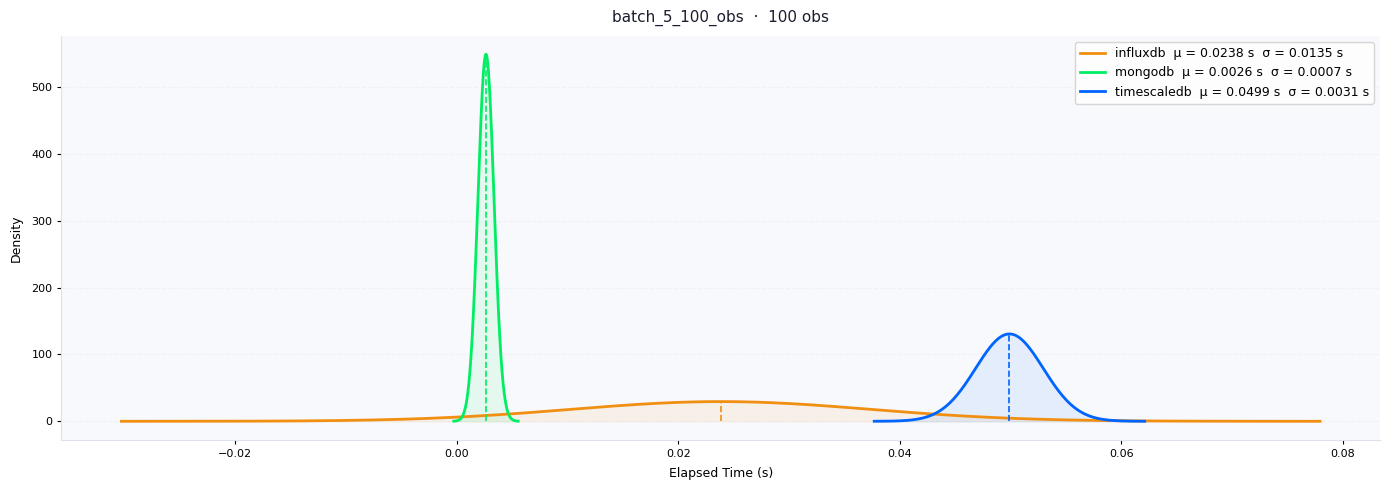

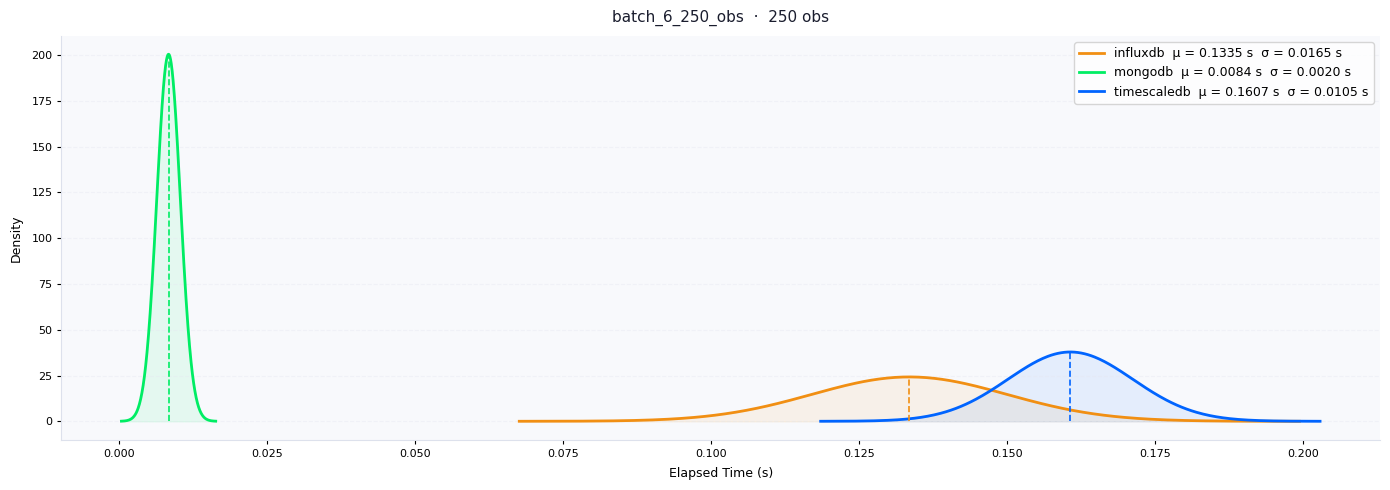

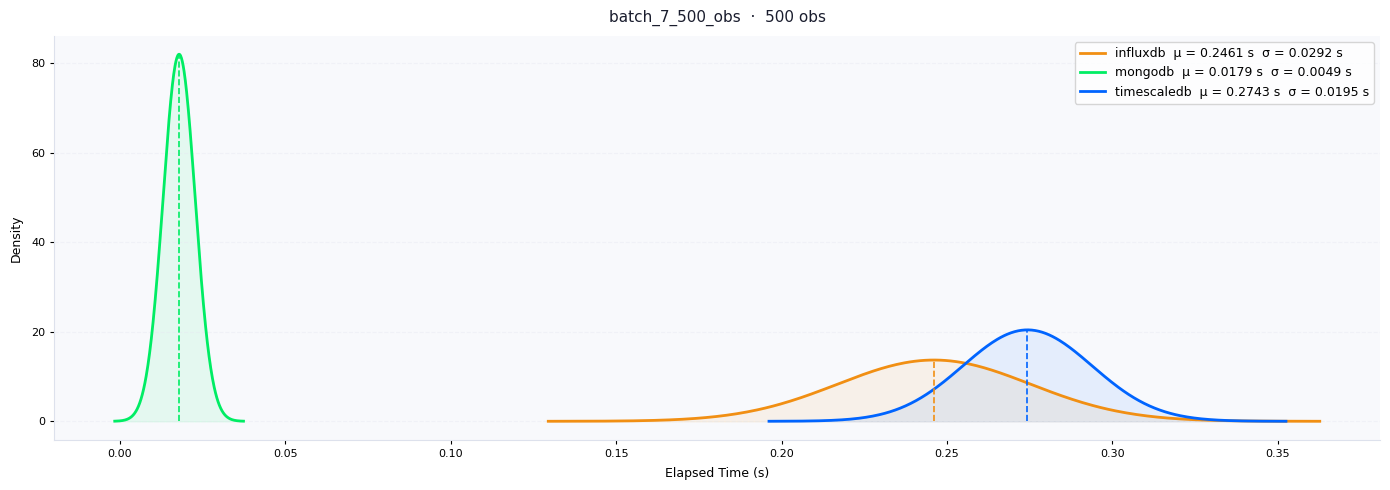

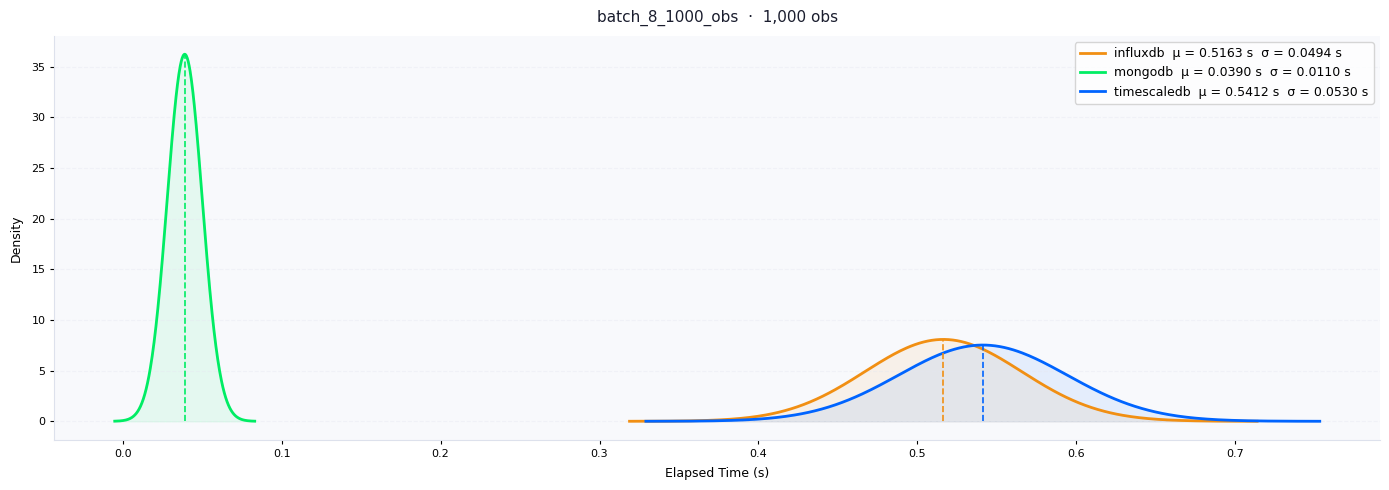

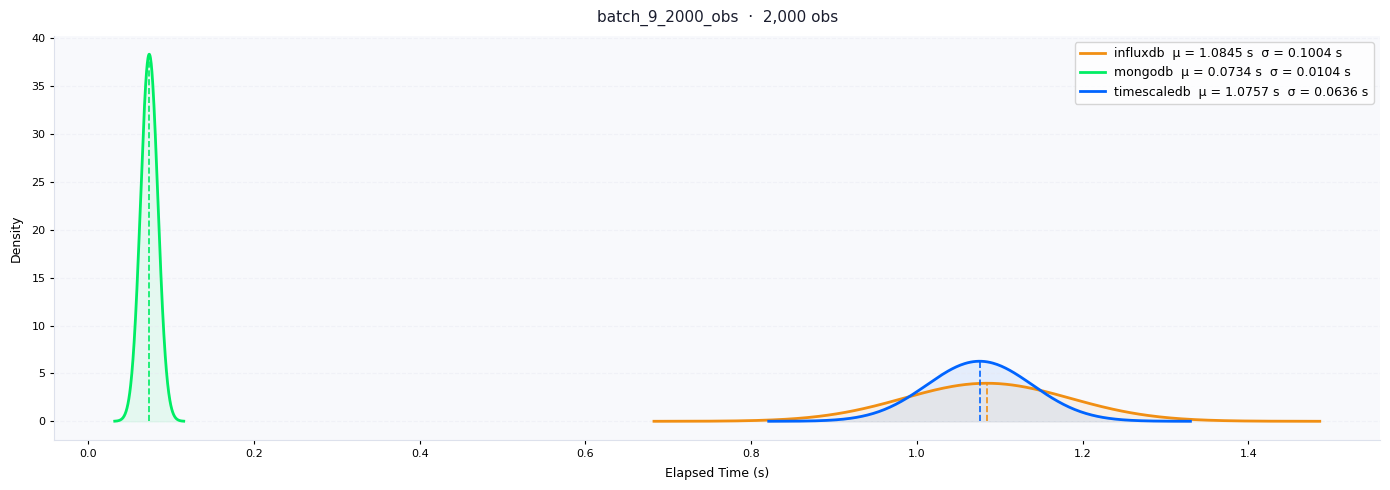

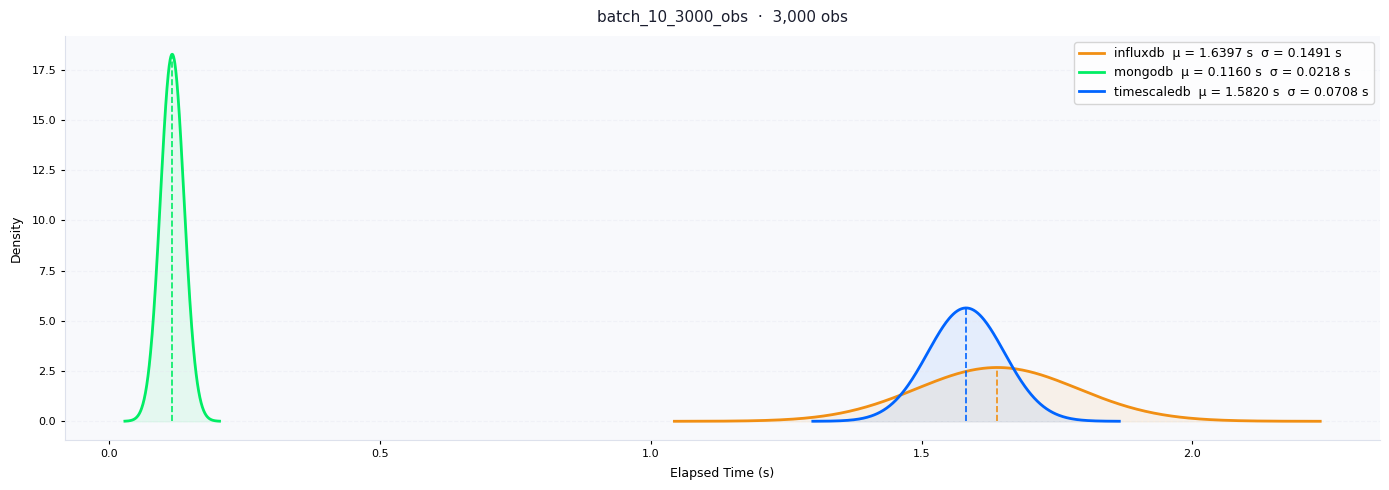

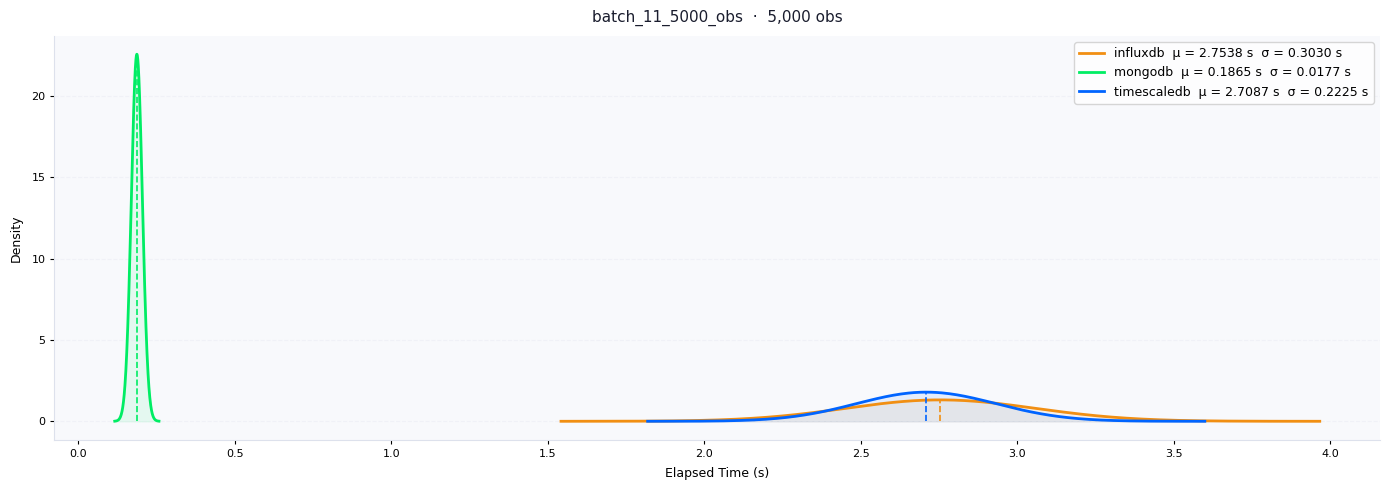

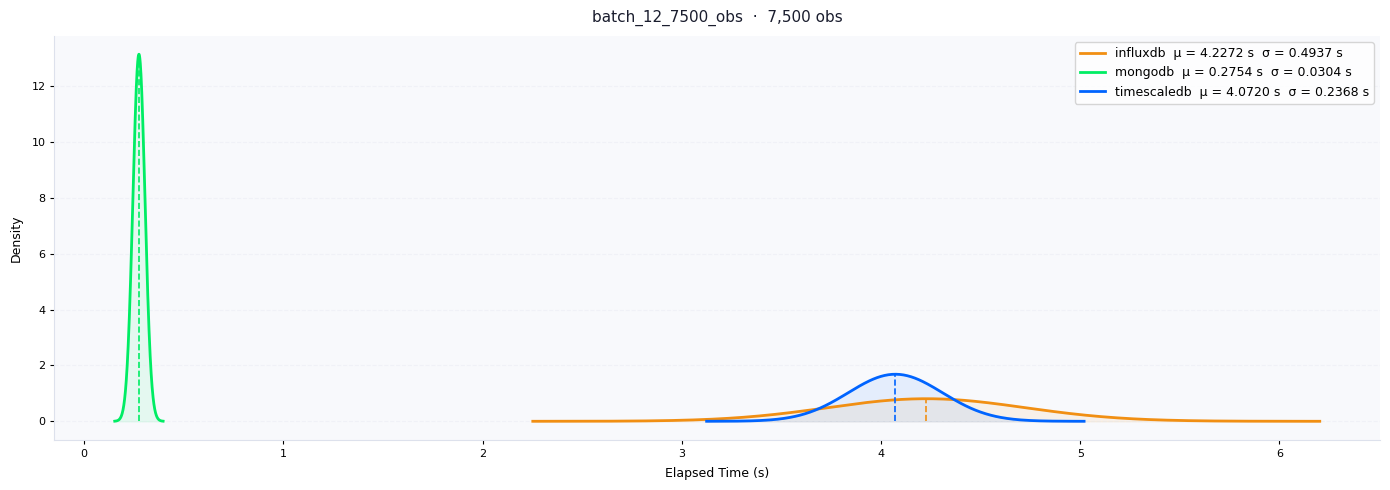

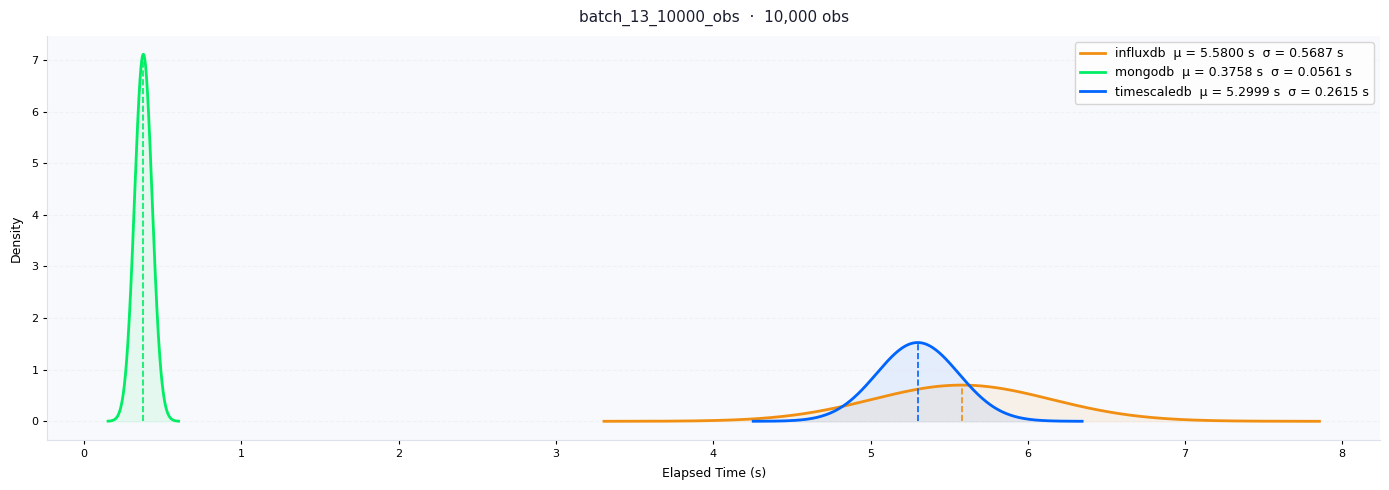

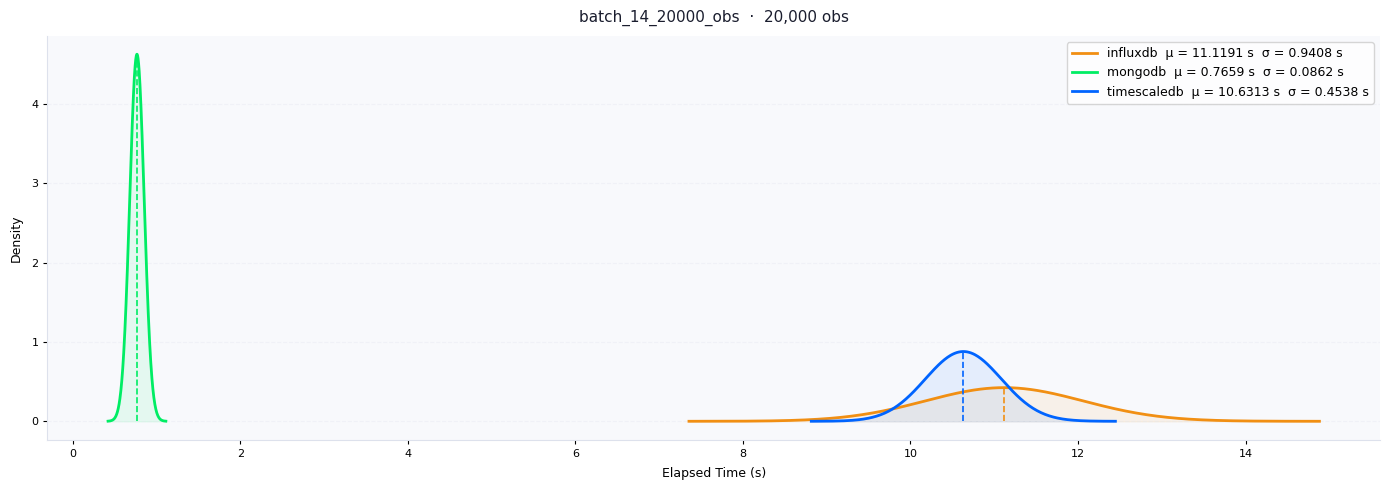

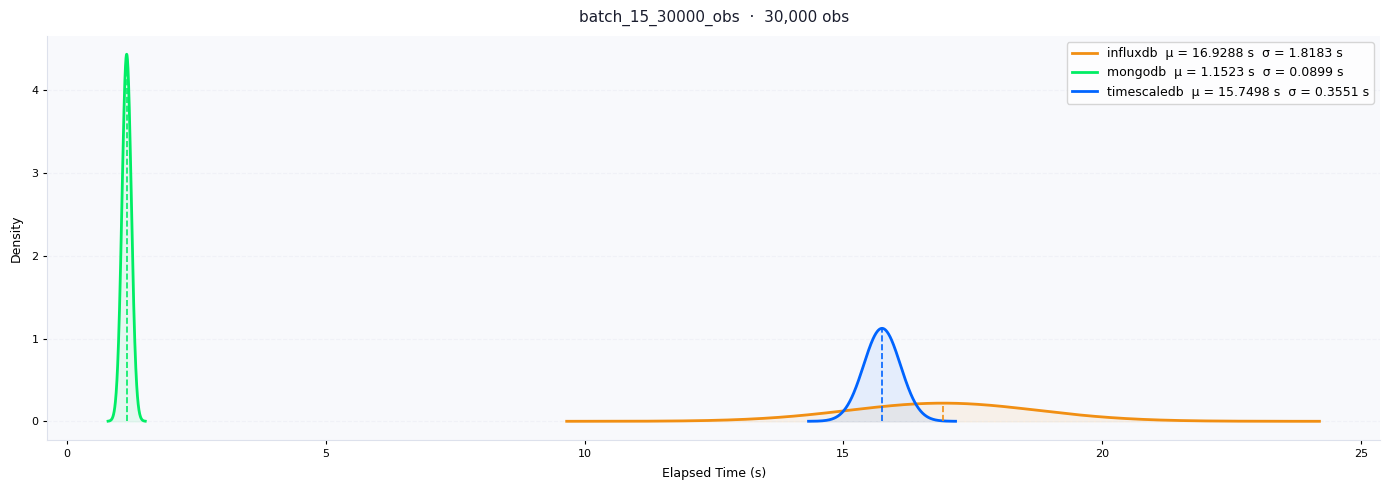

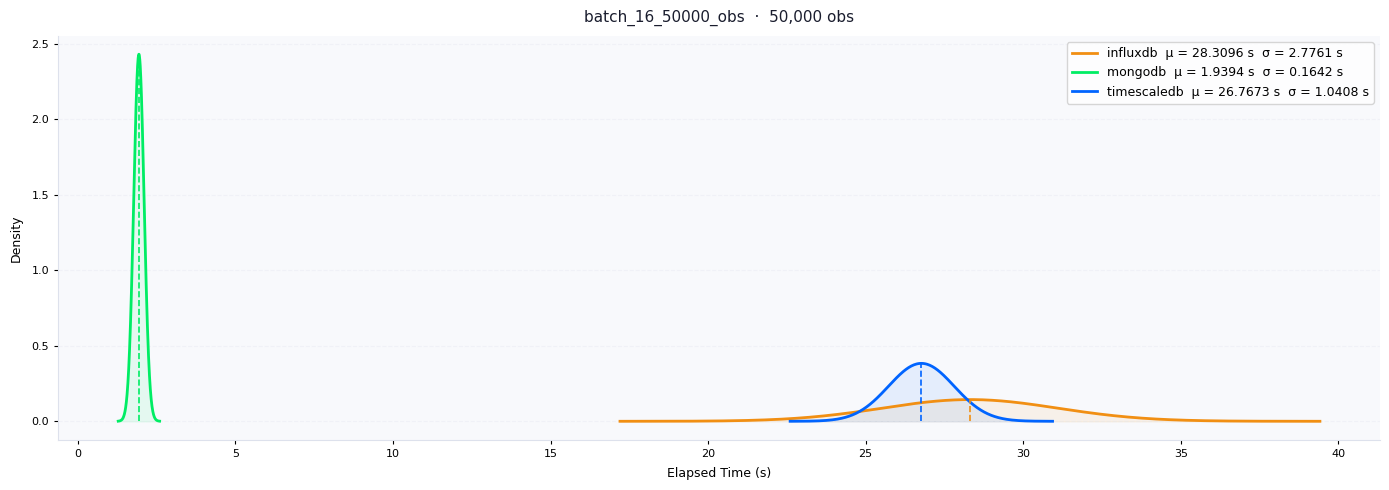

In [23]:
list_of_batch_ids = sorted({
    r.batch_id for db in db_systems for r in db_results[db]
})

for batch_id in list_of_batch_ids:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#f8f9fc')

    title_set = False

    for db in db_systems:
        batch = sorted(
            [r for r in db_results[db] if r.batch_id == batch_id],
            key=lambda r: r.created_at,
        )

        if len(batch) < 2:
            continue

        elapsed = [r.elapsed_time_seconds for r in batch]
        mu, std = norm.fit(elapsed)
        color   = db_color[db]

        x = np.linspace(mu - 4 * std, mu + 4 * std, 300)
        p = norm.pdf(x, mu, std)

        ax.fill_between(x, p, alpha=0.08, color=color)
        ax.plot(x, p, color=color, linewidth=2,
                label=f'{db}  μ = {mu:.4f} s  σ = {std:.4f} s')

        ax.plot([mu, mu], [0, norm.pdf(mu, mu, std)],
                color=color, linestyle='--', linewidth=1.2, zorder=3)

        if not title_set:
            ax.set_title(
                f'{batch[0].dataset_name}  ·  {batch[0].record_count:,} obs',
                fontsize=11, pad=10, color='#1a1d2e',
            )
            title_set = True

    ax.set_xlabel('Elapsed Time (s)', fontsize=9, labelpad=6)
    ax.set_ylabel('Density', fontsize=9, labelpad=6)
    ax.tick_params(axis='both', length=3, labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#dde1ec')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--')

    plt.tight_layout()
    plt.show()

## Throughput Comparison

One figure, all datasets on the x-axis.  
Grouped bars — one bar per database per dataset, colored by brand color.  
Y-axis is mean throughput in obs/s.

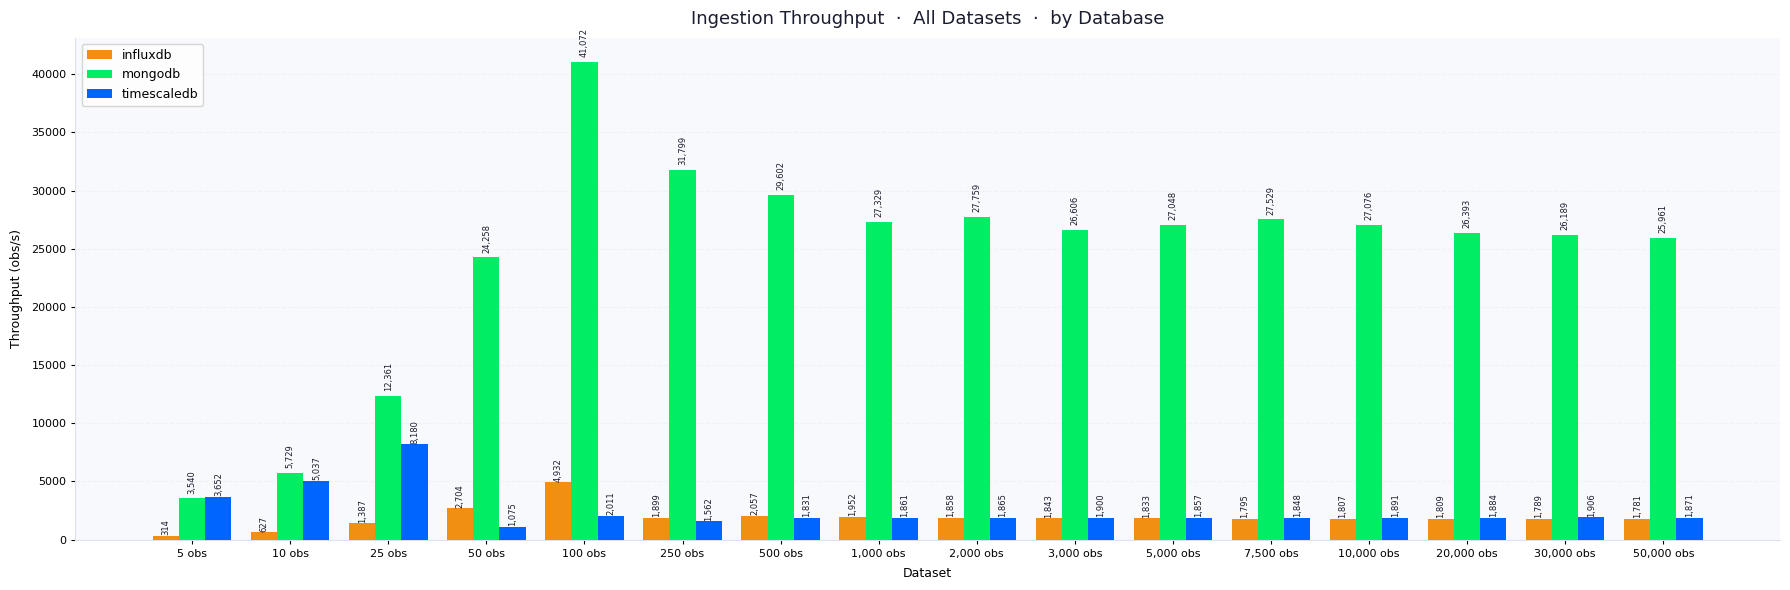

In [24]:
list_of_batch_ids = sorted({
    r.batch_id for db in db_systems for r in db_results[db]
})

x          = np.arange(len(list_of_batch_ids))
n_dbs      = len(db_systems)
bar_width  = 0.8 / n_dbs
x_labels   = []

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for i, db in enumerate(db_systems):
    means = []
    for batch_id in list_of_batch_ids:
        batch = [r for r in db_results[db] if r.batch_id == batch_id]
        means.append(np.mean([r.throughput_obs_per_sec for r in batch]) if batch else 0)

    offsets = x + i * bar_width - (n_dbs - 1) * bar_width / 2
    bars    = ax.bar(offsets, means, width=bar_width,
                     color=db_color[db], label=db, zorder=3)

    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(means) * 0.01,
                f'{val:,.0f}',
                ha='center', va='bottom', fontsize=6, color='#1a1d2e',
                rotation=90,
            )

# x tick labels — use dataset_name from first available db
for batch_id in list_of_batch_ids:
    first_r = next(
        r for db in db_systems
        for r in db_results[db]
        if r.batch_id == batch_id
    )
    # x_labels.append(f'{first_r.dataset_name}\n{first_r.record_count:,} obs')
    x_labels.append(f'{first_r.record_count:,} obs')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=7)
ax.set_xlabel('Dataset', fontsize=9, labelpad=6)
ax.set_ylabel('Throughput (obs/s)', fontsize=9, labelpad=6)
ax.set_title(
    'Ingestion Throughput  ·  All Datasets  ·  by Database',
    fontsize=13, pad=10, color='#1a1d2e',
)
ax.tick_params(axis='both', length=3, labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()